In [ ]:
# Export Configuration for Thesis
import os
from pathlib import Path

# Create export directories
EXPORT_BASE = Path('thesis_exports')
GRAPHS_DIR = EXPORT_BASE / 'graphs'
GRAPHS_DIR.mkdir(parents=True, exist_ok=True)

# Set high-quality figure settings for thesis
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.pad_inches'] = 0.1
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9

# Counter for graph filenames
graph_counter = {'count': 0}

def save_figure(fig, filename, format='png'):
    """Save figure to graphs directory"""
    graph_counter['count'] += 1
    filepath = GRAPHS_DIR / f"{graph_counter['count']:02d}_{filename}.{format}"
    fig.savefig(filepath, format=format, dpi=300, bbox_inches='tight')
    print(f"Saved: {filepath}")
    return filepath

print(f"Graphs will be exported to: {GRAPHS_DIR.absolute()}")


# slsbench 2.0.0 Evaluation Analysis

This notebook provides comprehensive analysis of slsbench 2.0.0 benchmarking results, comparing it with barista to validate the following hypothesis:

**Hypothesis 1: slsbench_2_0_0 is isolated** - Compare results with barista (with and without simulation)


In [249]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
from collections import defaultdict
import glob
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Data directory
DATA_DIR = Path('/home/bakhtinartyom1205/projects/harness-evaluation/data')


## Data Loading Functions


In [250]:
def parse_wrk2_output(file_path):
    """Parse wrk2 output file to extract latency percentiles and throughput"""
    with open(file_path, 'r') as f:
        content = f.read()
    
    result = {}
    
    # Extract throughput
    throughput_match = re.search(r'Requests/sec:\s*(\d+\.?\d*)', content)
    if throughput_match:
        result['throughput'] = float(throughput_match.group(1))
    
    # Extract latency percentiles - handle both formats
    percentiles = [50.0, 75.0, 90.0, 99.0, 99.9, 99.99, 99.999, 100.0]
    for p in percentiles:
        # Try multiple patterns to match different formats
        # Note: In Python strings, \\s becomes \s in the regex
        patterns = [
            # Format: "50.000%    1.61ms" - exact match with 3 decimals
            rf'{p:6.3f}%\s+([\d.]+)ms',
            # Format: "50.0%    1.61ms" - 1 decimal
            rf'{p:4.1f}%\s+([\d.]+)ms',
            # Format: "50%    1.61ms" - no decimal (for whole numbers)
            rf'{int(p)}%\s+([\d.]+)ms' if p == int(p) else None,
            # More flexible: match any whitespace
            rf'{p:6.3f}%\s+([\d.]+)ms',
        ]
        
        match = None
        for pattern in patterns:
            if pattern:
                try:
                    match = re.search(pattern, content)
                    if match:
                        break
                except:
                    continue
        
        if match:
            value = float(match.group(1))
            # Store as both p50 and p50.0 for compatibility
            # Store with the exact percentile value as key
            result[f'p{p}'] = value
            # Also create integer version for compatibility (e.g., p50 for 50.0)
            if p == int(p):
                result[f'p{int(p)}'] = value
            # Also store as p50.0 format for exact matching
            if p == int(p):
                result[f'p{int(p)}.0'] = value
    
    # Extract average latency
    avg_match = re.search(r'Latency\\s+([\\d.]+)ms', content)
    if avg_match:
        result['avg_latency'] = float(avg_match.group(1))
    
    return result

def load_barista_media_results(result_dir):
    """Load barista media results from wrk2 output files"""
    results = []
    
    for wrk2_file in sorted(result_dir.glob('*.txt')):
        try:
            parsed = parse_wrk2_output(wrk2_file)
            if parsed:
                parsed['run'] = wrk2_file.stem  # e.g., 'localhost:8080_run1'
                results.append(parsed)
        except Exception as e:
            print(f"Error loading barista media result from {wrk2_file}: {e}")
    
    if results:
        return pd.DataFrame(results)
    return pd.DataFrame()

def load_barista_results(result_dir):
    """Load barista benchmark results from a result directory"""
    results = []
    
    for run_dir in sorted(result_dir.glob('run_*')):
        json_file = run_dir / 'barista-results.json'
        if json_file.exists():
            with open(json_file, 'r') as f:
                data = json.load(f)
            
            # Extract latency measurements
            latency_data = data.get('latency', {}).get('measurements', {}).get('final_measurements', [])
            if latency_data:
                for measurement in latency_data:
                    result = {
                        'run': run_dir.name,
                        'rate': measurement.get('rate', 0),
                        'p50': measurement.get('p_values', {}).get('50.0', 0),
                        'p75': measurement.get('p_values', {}).get('75.0', 0),
                        'p90': measurement.get('p_values', {}).get('90.0', 0),
                        'p99': measurement.get('p_values', {}).get('99.0', 0),
                        'p99.9': measurement.get('p_values', {}).get('99.9', 0),
                        'p99.99': measurement.get('p_values', {}).get('99.99', 0),
                        'p99.999': measurement.get('p_values', {}).get('99.999', 0),
                        'p100': measurement.get('p_values', {}).get('100.0', 0),
                    }
                    results.append(result)
    
    return pd.DataFrame(results)

def load_harness_2_0_0_results(result_dir):
    """Load slsbench 2.0.0 harness results"""
    results = []
    
    for run_dir in sorted(result_dir.glob('result-*')):
        wrk2_file = None
        for file in run_dir.glob('wrk2_results_*.txt'):
            wrk2_file = file
            break
        
        if wrk2_file and wrk2_file.exists():
            wrk2_data = parse_wrk2_output(wrk2_file)
            wrk2_data['run'] = run_dir.name
            
            # Check for JFR file
            jfr_file = run_dir / 'collected' / 'logs' / 'recording.jfr'
            wrk2_data['has_jfr'] = jfr_file.exists()
            
            results.append(wrk2_data)
    
    df = pd.DataFrame(results)
    
    # Normalize column names: ensure p50 exists (prefer p50 over p50.0)
    if len(df) > 0:
        columns_to_drop = []
        column_mapping = {}
        for col in df.columns:
            if col.startswith('p') and '.' in col:
                try:
                    num = float(col[1:])
                    if num == int(num):
                        int_col = f'p{int(num)}'
                        # If p50 already exists, we'll drop p50.0
                        if int_col in df.columns:
                            columns_to_drop.append(col)
                        # If p50 doesn't exist, rename p50.0 to p50
                        else:
                            column_mapping[col] = int_col
                except:
                    pass
        if column_mapping:
            df = df.rename(columns=column_mapping)
        if columns_to_drop:
            df = df.drop(columns=columns_to_drop)
    
    return df

def load_harness_1_0_0_results(result_dir):
    """Load slsbench 1.0.0 harness results"""
    results = []
    
    for run_dir in sorted(result_dir.glob('result-*')):
        wrk2_file = run_dir / '0-mixed-requests.lua.out'
        
        if wrk2_file.exists():
            wrk2_data = parse_wrk2_output(wrk2_file)
            wrk2_data['run'] = run_dir.name
            
            # Check for JFR file
            jfr_dir = run_dir / 'jfr'
            wrk2_data['has_jfr'] = jfr_dir.exists() and len(list(jfr_dir.glob('*.jfr'))) > 0
            
            results.append(wrk2_data)
    
    df = pd.DataFrame(results)
    
    # Normalize column names: ensure p50 exists (prefer p50 over p50.0)
    if len(df) > 0:
        columns_to_drop = []
        column_mapping = {}
        for col in df.columns:
            if col.startswith('p') and '.' in col:
                try:
                    num = float(col[1:])
                    if num == int(num):
                        int_col = f'p{int(num)}'
                        # If p50 already exists, we'll drop p50.0
                        if int_col in df.columns:
                            columns_to_drop.append(col)
                        # If p50 doesn't exist, rename p50.0 to p50
                        else:
                            column_mapping[col] = int_col
                except:
                    pass
        if column_mapping:
            df = df.rename(columns=column_mapping)
        if columns_to_drop:
            df = df.drop(columns=columns_to_drop)
    
    return df

def load_first_request_data(result_dir, harness_version='2.0.0'):
    """Load first request timing data"""
    results = []
    
    pattern = 'result-*' if harness_version == '2.0.0' else 'result-*'
    
    for run_dir in sorted(result_dir.glob(pattern)):
        if harness_version == '2.0.0':
            first_req_file = run_dir / 'first_request_result.json'
        else:
            first_req_file = run_dir / 'first-response.csv'
        
        if first_req_file.exists():
            try:
                if harness_version == '2.0.0':
                    with open(first_req_file, 'r') as f:
                        data = json.load(f)
                        results.append({
                            'run': run_dir.name,
                            'time_to_first_success_ms': data.get('time_to_first_success_ms', 0),
                            'total_attempts': data.get('total_attempts', 0),
                            'final_status_code': data.get('final_status_code', 0)
                        })
                else:
                    # Harness 1.0.0 uses CSV
                    df = pd.read_csv(first_req_file)
                    if len(df) > 0:
                        # Calculate time difference
                        df['benchmark_container_start_timestamp'] = pd.to_datetime(df['benchmark_container_start_timestamp'])
                        df['response_timestamp'] = pd.to_datetime(df['response_timestamp'])
                        time_diff = (df['response_timestamp'] - df['benchmark_container_start_timestamp']).dt.total_seconds() * 1000
                        results.append({
                            'run': run_dir.name,
                            'time_to_first_success_ms': time_diff.iloc[0] if len(time_diff) > 0 else 0,
                            'total_attempts': 1,
                            'final_status_code': 200
                        })
            except Exception as e:
                print(f"Error loading first request data from {first_req_file}: {e}")
    
    return pd.DataFrame(results)

def load_container_stats(result_dir, harness_version='2.0.0'):
    """Load container resource usage statistics"""
    all_stats = []
    
    pattern = 'result-*' if harness_version == '2.0.0' else 'result-*'
    
    for run_dir in sorted(result_dir.glob(pattern)):
        stats_file = run_dir / 'container-stats.csv'
        if stats_file.exists():
            try:
                df = pd.read_csv(stats_file)
                df['run'] = run_dir.name
                # Parse timestamp if present - handle Go timestamp format
                if 'timestamp' in df.columns:
                    # Go timestamp format: "2026-01-05 22:43:26.097130987 +0000 UTC m=+0.638557475"
                    # Extract just the datetime part before "UTC"
                    def parse_go_timestamp(ts_str):
                        if pd.isna(ts_str):
                            return pd.NaT
                        try:
                            # Try to extract the datetime part before "UTC"
                            if ' UTC ' in str(ts_str):
                                ts_str = str(ts_str).split(' UTC ')[0]
                            # Parse the datetime
                            return pd.to_datetime(ts_str, errors='coerce')
                        except:
                            return pd.NaT
                    
                    df['timestamp'] = df['timestamp'].apply(parse_go_timestamp)
                all_stats.append(df)
            except Exception as e:
                print(f"Error loading container stats from {stats_file}: {e}")
    
    if all_stats:
        return pd.concat(all_stats, ignore_index=True)
    return pd.DataFrame()

def load_barista_startup_data(result_dir):
    """Load barista startup/first request data"""
    results = []
    
    for run_dir in sorted(result_dir.glob('run_*')):
        json_file = run_dir / 'barista-results.json'
        if json_file.exists():
            with open(json_file, 'r') as f:
                data = json.load(f)
            
            # Extract startup data
            startup_data = data.get('startup', {})
            if startup_data:
                self_reported = startup_data.get('self_reported', {})
                results.append({
                    'run': run_dir.name,
                    'framework_startup_ms': self_reported.get('framework-startup', 0),
                    'process_startup_ms': self_reported.get('process-startup', 0),
                    'total_startup_ms': self_reported.get('framework-startup', 0) + self_reported.get('process-startup', 0)
                })
    
    return pd.DataFrame(results)

def flatten_to_1d(data):
    """Safely flatten data to 1D list of numeric values"""
    # Handle pandas DataFrame - convert to Series or extract values
    if isinstance(data, pd.DataFrame):
        if len(data.columns) == 1:
            # Single column DataFrame - convert to Series
            data = data.iloc[:, 0]
        else:
            # Multiple columns - flatten all values
            data = data.values.flatten()
    
    # Handle pandas Series - convert to numpy array
    if isinstance(data, pd.Series):
        data = data.values
    
    if isinstance(data, (list, tuple, np.ndarray)):
        # Convert to numpy array and flatten
        arr = np.array(data, dtype=object)
        # Flatten recursively if needed
        while arr.ndim > 1:
            arr = arr.flatten()
        # Convert to list and filter
        result = []
        for item in arr:
            if isinstance(item, (int, float)) and not (isinstance(item, float) and np.isnan(item)):
                result.append(float(item))
            elif isinstance(item, (list, tuple, np.ndarray)):
                # Recursively flatten nested structures
                nested = flatten_to_1d(item)
                result.extend(nested)
        return result
    elif isinstance(data, (int, float)):
        return [float(data)] if not (isinstance(data, float) and np.isnan(data)) else []
    else:
        return []

def load_barista_resource_usage(result_dir):
    """Load barista resource usage data"""
    all_stats = []
    
    for run_dir in sorted(result_dir.glob('run_*')):
        stats_file = run_dir / 'barista_resource_usage.csv'
        if stats_file.exists():
            try:
                df = pd.read_csv(stats_file)
                df['run'] = run_dir.name
                all_stats.append(df)
            except Exception as e:
                print(f"Error loading barista resource usage from {stats_file}: {e}")
    
    if all_stats:
        return pd.concat(all_stats, ignore_index=True)
    return pd.DataFrame()

def load_harness_rss_info(result_dir):
    """Load RSS information from harness 2.0.0 rss_info.json files"""
    all_rss_data = []
    
    for run_dir in sorted(result_dir.glob('result-*')):
        rss_file = run_dir / 'rss_info.json'
        if rss_file.exists():
            try:
                with open(rss_file, 'r') as f:
                    data = json.load(f)
                
                # Extract RSS values from all timestamps
                for entry in data:
                    timestamp = entry.get('timestamp', '')
                    processes = entry.get('processes', [])
                    for proc in processes:
                        rss_kb = int(proc.get('rss', 0))
                        rss_mb = rss_kb / 1024  # Convert KB to MB
                        all_rss_data.append({
                            'run': run_dir.name,
                            'timestamp': timestamp,
                            'rss_mb': rss_mb,
                            'pid': proc.get('pid', '')
                        })
            except Exception as e:
                print(f"Error loading RSS info from {rss_file}: {e}")
    
    if all_rss_data:
        df = pd.DataFrame(all_rss_data)
        if 'timestamp' in df.columns:
            df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
        return df
    return pd.DataFrame()


## Load All Results


In [251]:
# Load barista results (baseline)
barista_petclinic_jvm = load_barista_results(DATA_DIR / 'results-petclinic-jvm')
barista_petclinic_native = load_barista_results(DATA_DIR / 'results-petclinic-native')
barista_shopcart_jvm = load_barista_results(DATA_DIR / 'results-shopcart-jvm')
barista_shopcart_native = load_barista_results(DATA_DIR / 'results-shopcart-native')

# Load barista simulation results (isolation test)
barista_petclinic_sim_jvm = load_barista_results(DATA_DIR / 'results_petclinic-sim-jvm')
barista_petclinic_sim_native = load_barista_results(DATA_DIR / 'results_petclinic-sim-native')
barista_shopcart_sim_jvm = load_barista_results(DATA_DIR / 'results_shopcart-sim-jvm')
barista_shopcart_sim_native = load_barista_results(DATA_DIR / 'results_shopcart-sim-native')

# Load harness 2.0.0 results
harness_2_petclinic_jvm_g1gc = load_harness_2_0_0_results(DATA_DIR / 'results-petclinic-harness_2_0_0-jvm-g1gc-run')
harness_2_petclinic_jvm_shenandoah = load_harness_2_0_0_results(DATA_DIR / 'results-petclinic-harness_2_0_0-jvm-shenandoah-run')
harness_2_petclinic_native = load_harness_2_0_0_results(DATA_DIR / 'results-petclinic-harness_2_0_0-native-run')
harness_2_shopcart_jvm_g1gc = load_harness_2_0_0_results(DATA_DIR / 'results-shopcart-harness_2_0_0-jvm-g1gc-run')
harness_2_shopcart_jvm_shenandoah = load_harness_2_0_0_results(DATA_DIR / 'results-shopcart-harness_2_0_0-jvm-shenandoah-run')
harness_2_shopcart_native = load_harness_2_0_0_results(DATA_DIR / 'results-shopcart-harness_2_0_0-native-run')
harness_2_media = load_harness_2_0_0_results(DATA_DIR / 'results-media-harness_2_0_0-run')

# Load harness 1.0.0 results
harness_1_petclinic_jvm_g1gc = load_harness_1_0_0_results(DATA_DIR / 'results_petclinic-harness_1_0_0-jvm-g1gc')
harness_1_petclinic_jvm_shenandoah = load_harness_1_0_0_results(DATA_DIR / 'results_petclinic-harness_1_0_0-jvm-shenandoah')
harness_1_petclinic_native = load_harness_1_0_0_results(DATA_DIR / 'results_petclinic-harness_1_0_0-native')
harness_1_shopcart_jvm_g1gc = load_harness_1_0_0_results(DATA_DIR / 'results_shopcart-harness_1_0_0-jvm-g1gc')
harness_1_shopcart_jvm_shenandoah = load_harness_1_0_0_results(DATA_DIR / 'results_shopcart-harness_1_0_0-jvm-shenandoah')
harness_1_shopcart_native = load_harness_1_0_0_results(DATA_DIR / 'results_shopcart-harness_1_0_0-native')

# Load first request data
barista_petclinic_jvm_startup = load_barista_startup_data(DATA_DIR / 'results-petclinic-jvm')
barista_petclinic_sim_jvm_startup = load_barista_startup_data(DATA_DIR / 'results_petclinic-sim-jvm')
harness_2_petclinic_jvm_g1gc_first = load_first_request_data(DATA_DIR / 'results-petclinic-harness_2_0_0-jvm-g1gc-run', '2.0.0')
harness_2_petclinic_native_first = load_first_request_data(DATA_DIR / 'results-petclinic-harness_2_0_0-native-run', '2.0.0')

# Load container stats
harness_2_petclinic_jvm_g1gc_stats = load_container_stats(DATA_DIR / 'results-petclinic-harness_2_0_0-jvm-g1gc-run', '2.0.0')
harness_2_petclinic_native_stats = load_container_stats(DATA_DIR / 'results-petclinic-harness_2_0_0-native-run', '2.0.0')
barista_petclinic_jvm_stats = load_barista_resource_usage(DATA_DIR / 'results-petclinic-jvm')
barista_petclinic_sim_jvm_stats = load_barista_resource_usage(DATA_DIR / 'results_petclinic-sim-jvm')

# Load shopcart container stats
barista_shopcart_jvm_stats = load_barista_resource_usage(DATA_DIR / 'results-shopcart-jvm')
barista_shopcart_sim_jvm_stats = load_barista_resource_usage(DATA_DIR / 'results_shopcart-sim-jvm')
harness_2_shopcart_jvm_g1gc_stats = load_container_stats(DATA_DIR / 'results-shopcart-harness_2_0_0-jvm-g1gc-run', '2.0.0')
harness_2_shopcart_jvm_shenandoah_stats = load_container_stats(DATA_DIR / 'results-shopcart-harness_2_0_0-jvm-shenandoah-run', '2.0.0')
harness_1_shopcart_jvm_g1gc_stats = load_container_stats(DATA_DIR / 'results_shopcart-harness_1_0_0-jvm-g1gc', '1.0.0')
harness_1_shopcart_jvm_shenandoah_stats = load_container_stats(DATA_DIR / 'results_shopcart-harness_1_0_0-jvm-shenandoah', '1.0.0')

# Load shopcart RSS info
harness_2_shopcart_jvm_g1gc_rss = load_harness_rss_info(DATA_DIR / 'results-shopcart-harness_2_0_0-jvm-g1gc-run')
harness_2_shopcart_jvm_shenandoah_rss = load_harness_rss_info(DATA_DIR / 'results-shopcart-harness_2_0_0-jvm-shenandoah-run')
harness_1_shopcart_jvm_g1gc_rss = load_harness_rss_info(DATA_DIR / 'results_shopcart-harness_1_0_0-jvm-g1gc')
harness_1_shopcart_jvm_shenandoah_rss = load_harness_rss_info(DATA_DIR / 'results_shopcart-harness_1_0_0-jvm-shenandoah')

# Load media results
barista_media = load_barista_media_results(DATA_DIR / 'results-media')
harness_2_media = load_harness_2_0_0_results(DATA_DIR / 'results-media-harness_2_0_0-run')
harness_2_media_first = load_first_request_data(DATA_DIR / 'results-media-harness_2_0_0-run', '2.0.0')
harness_2_media_stats = load_container_stats(DATA_DIR / 'results-media-harness_2_0_0-run', '2.0.0')
harness_2_media_rss = load_harness_rss_info(DATA_DIR / 'results-media-harness_2_0_0-run')

# Load RSS info from harness 2.0.0
harness_2_petclinic_jvm_g1gc_rss = load_harness_rss_info(DATA_DIR / 'results-petclinic-harness_2_0_0-jvm-g1gc-run')
harness_2_petclinic_jvm_shenandoah_rss = load_harness_rss_info(DATA_DIR / 'results-petclinic-harness_2_0_0-jvm-shenandoah-run')

# Load RSS info and stats from harness 1.0.0
harness_1_petclinic_jvm_g1gc_rss = load_harness_rss_info(DATA_DIR / 'results_petclinic-harness_1_0_0-jvm-g1gc')
harness_1_petclinic_jvm_shenandoah_rss = load_harness_rss_info(DATA_DIR / 'results_petclinic-harness_1_0_0-jvm-shenandoah')
harness_1_petclinic_jvm_g1gc_stats = load_container_stats(DATA_DIR / 'results_petclinic-harness_1_0_0-jvm-g1gc', '1.0.0')
harness_1_petclinic_jvm_shenandoah_stats = load_container_stats(DATA_DIR / 'results_petclinic-harness_1_0_0-jvm-shenandoah', '1.0.0')
harness_2_petclinic_jvm_shenandoah_stats = load_container_stats(DATA_DIR / 'results-petclinic-harness_2_0_0-jvm-shenandoah-run', '2.0.0')

print("Data loaded successfully!")
print(f"Barista petclinic JVM runs: {len(barista_petclinic_jvm)}")
print(f"Barista petclinic JVM (sim) runs: {len(barista_petclinic_sim_jvm)}")
print(f"Harness 2.0.0 petclinic JVM G1GC runs: {len(harness_2_petclinic_jvm_g1gc)}")
print(f"Harness 2.0.0 petclinic native runs: {len(harness_2_petclinic_native)}")
print(f"Harness 1.0.0 petclinic native runs: {len(harness_1_petclinic_native)}")
print(f"\nFirst request data:")
print(f"  Barista petclinic JVM: {len(barista_petclinic_jvm_startup)}")
print(f"  Barista petclinic JVM (sim): {len(barista_petclinic_sim_jvm_startup)}")
print(f"  Harness 2.0.0 petclinic JVM G1GC: {len(harness_2_petclinic_jvm_g1gc_first)}")
print(f"\nContainer stats:")
print(f"  Harness 2.0.0 petclinic JVM G1GC: {len(harness_2_petclinic_jvm_g1gc_stats)} rows")
print(f"  Barista petclinic JVM: {len(barista_petclinic_jvm_stats)} rows")
print(f"  Barista petclinic JVM (sim): {len(barista_petclinic_sim_jvm_stats)} rows")
print(f"\nRSS info:")
print(f"  Harness 2.0.0 petclinic JVM G1GC: {len(harness_2_petclinic_jvm_g1gc_rss)} rows")
print(f"\nMedia results:")
print(f"  Death Star Bench media runs: {len(barista_media)}")
print(f"  Harness 2.0.0 media runs: {len(harness_2_media)}")
print(f"  Harness 2.0.0 media first request: {len(harness_2_media_first)}")
print(f"  Harness 2.0.0 media stats: {len(harness_2_media_stats)} rows")
print(f"  Harness 2.0.0 media RSS: {len(harness_2_media_rss)} rows")


Data loaded successfully!
Barista petclinic JVM runs: 5
Barista petclinic JVM (sim) runs: 5
Harness 2.0.0 petclinic JVM G1GC runs: 5
Harness 2.0.0 petclinic native runs: 5
Harness 1.0.0 petclinic native runs: 5

First request data:
  Barista petclinic JVM: 5
  Barista petclinic JVM (sim): 5
  Harness 2.0.0 petclinic JVM G1GC: 5

Container stats:
  Harness 2.0.0 petclinic JVM G1GC: 204 rows
  Barista petclinic JVM: 7316 rows
  Barista petclinic JVM (sim): 7173 rows

RSS info:
  Harness 2.0.0 petclinic JVM G1GC: 197 rows

Media results:
  Death Star Bench media runs: 5
  Harness 2.0.0 media runs: 5
  Harness 2.0.0 media first request: 5
  Harness 2.0.0 media stats: 171 rows
  Harness 2.0.0 media RSS: 810 rows


## Hypothesis 1: slsbench_2_0_0 is Isolated

Compare results with barista (with and without simulation) to verify isolation.


HYPOTHESIS 1: slsbench_2_0_0 is Isolated

1. FIRST REQUEST TIME COMPARISON
--------------------------------------------------------------------------------
                              mean         std           min           max
Source                                                                    
Barista (Normal)       9634.800000  112.686290   9533.000000   9818.000000
Barista (Simulation)  15935.200000  850.245964  14939.000000  16780.000000
Harness 2.0.0          7242.120457  179.893537   6945.759058   7383.392096


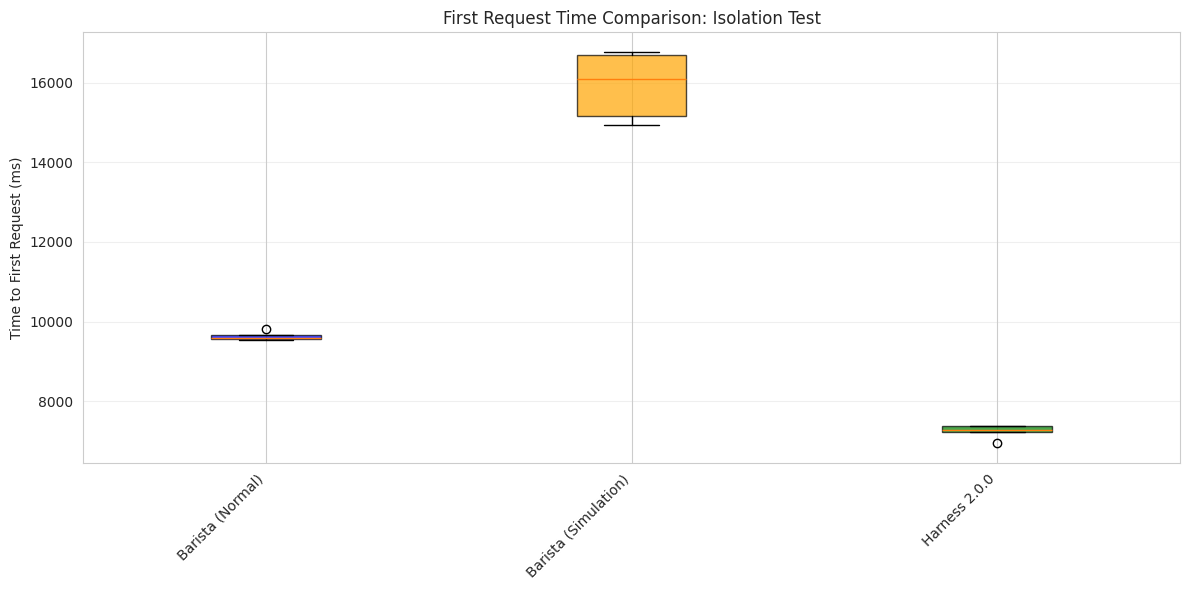


2. LATENCY COMPARISON
--------------------------------------------------------------------------------

Barista (Normal) vs Barista (Simulation):
Percentile  Barista Normal Mean  Barista Normal Std  Barista Simulation Mean  Barista Simulation Std  Difference (%)
       p50               3618.0          290.637231                  13628.0              775.802810      276.672195
       p75               4120.0          143.701079                  15810.0              737.122785      283.737864
       p90               4408.0          138.455769                  17004.0              873.286894      285.753176
       p99               4822.0          177.115781                  17730.0              871.177364      267.689755
     p99.9               4982.0          217.531607                  17960.0              836.928910      260.497792

Barista (Normal) vs Harness 2.0.0:
Empty DataFrame
Columns: []
Index: []

Barista (Simulation) vs Harness 2.0.0:
Empty DataFrame
Columns: []
Index: []

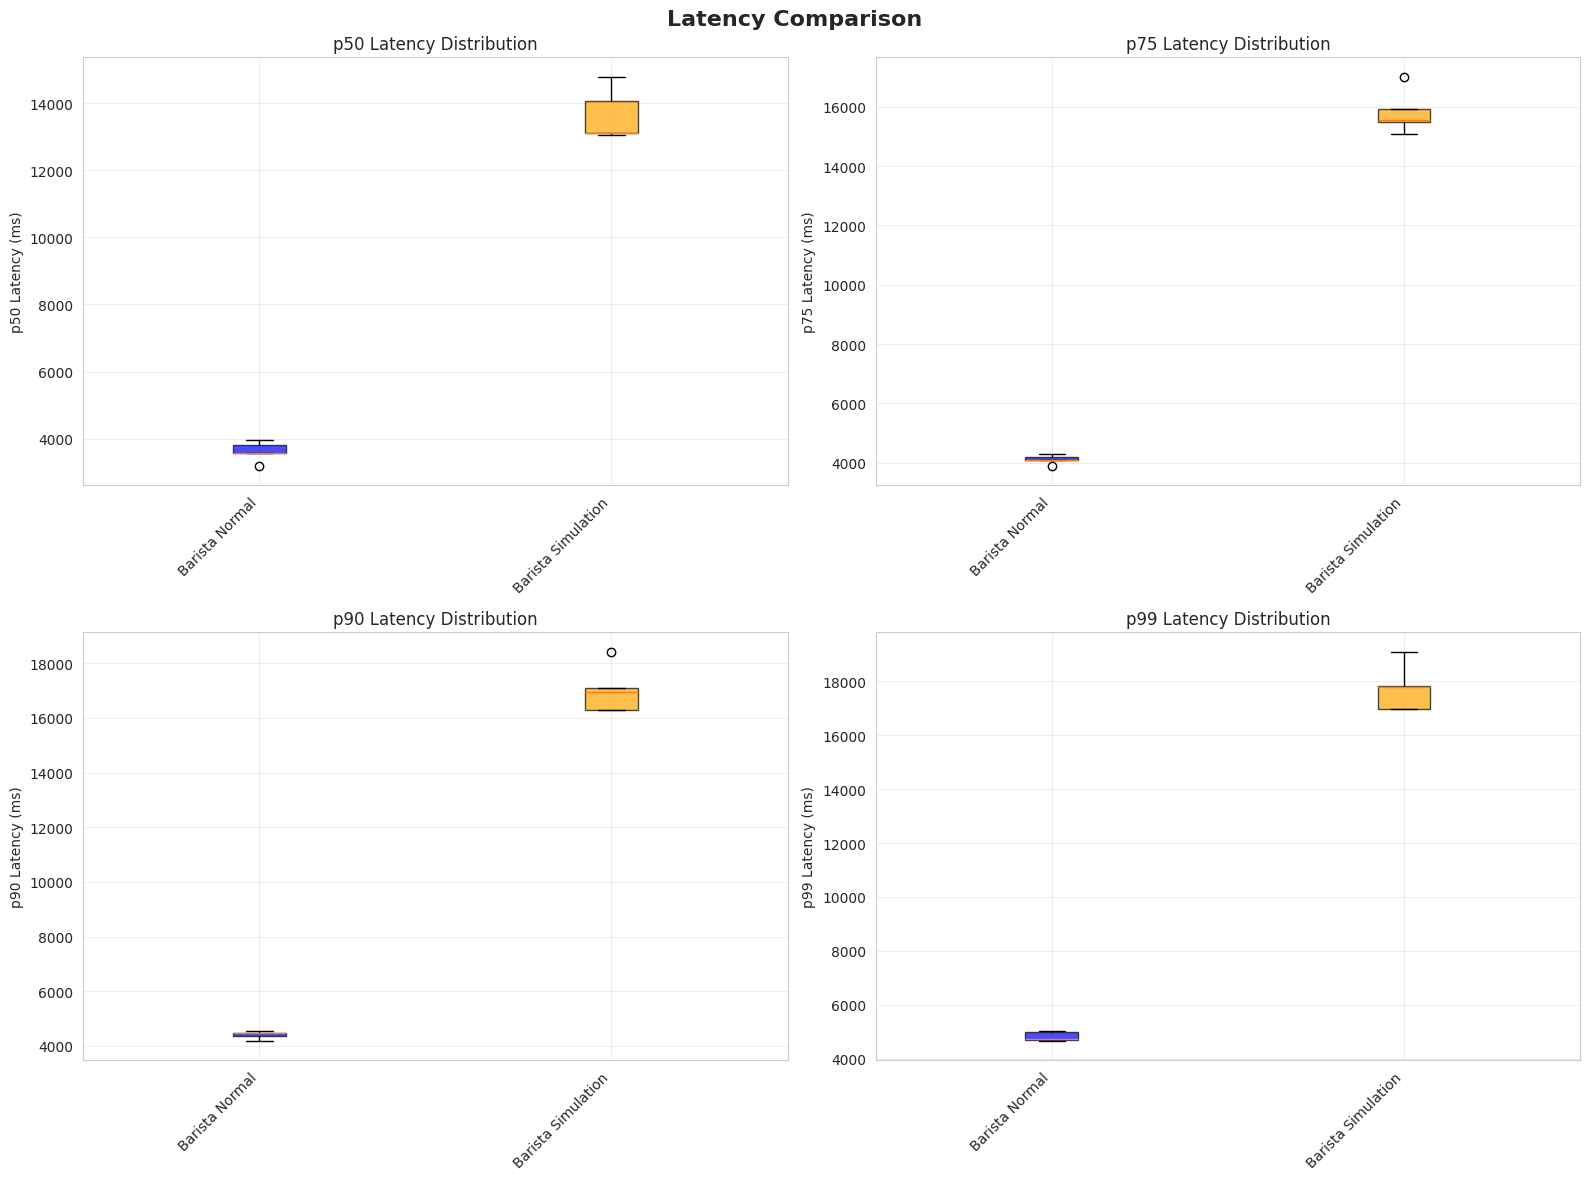


=== Debug: Available columns in datasets ===
Barista Normal columns: ['run', 'rate', 'p50', 'p75', 'p90', 'p99', 'p99.9', 'p99.99', 'p99.999', 'p100']
Barista Simulation columns: ['run', 'rate', 'p50', 'p75', 'p90', 'p99', 'p99.9', 'p99.99', 'p99.999', 'p100']
Harness 2.0.0 columns: ['throughput', 'run', 'has_jfr']

3. THROUGHPUT COMPARISON
--------------------------------------------------------------------------------
                        mean       std      min      max
Source                                                  
Barista Normal      3000.000  0.000000  3000.00  3000.00
Barista Simulation  3000.000  0.000000  3000.00  3000.00
Harness 2.0.0        152.296  9.415351   145.42   162.61


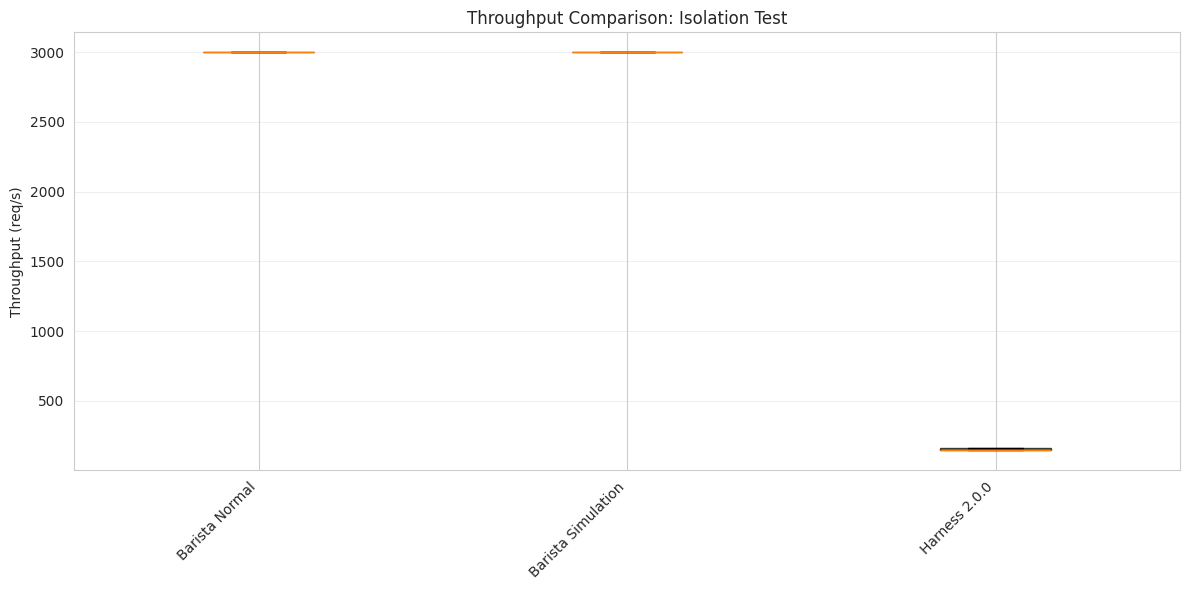

In [252]:
# Comprehensive Hypothesis 1 Analysis: Isolation Comparison
print("="*80)
print("HYPOTHESIS 1: slsbench_2_0_0 is Isolated")
print("="*80)

# 1. First Request Time Comparison
print("\n1. FIRST REQUEST TIME COMPARISON")
print("-" * 80)

first_req_data = []

if len(barista_petclinic_jvm_startup) > 0:
    for _, row in barista_petclinic_jvm_startup.iterrows():
        first_req_data.append({
            'Source': 'Barista (Normal)',
            'Time to First Request (ms)': row.get('total_startup_ms', 0),
            'Run': row.get('run', '')
        })

if len(barista_petclinic_sim_jvm_startup) > 0:
    for _, row in barista_petclinic_sim_jvm_startup.iterrows():
        first_req_data.append({
            'Source': 'Barista (Simulation)',
            'Time to First Request (ms)': row.get('total_startup_ms', 0),
            'Run': row.get('run', '')
        })

if len(harness_2_petclinic_jvm_g1gc_first) > 0:
    for _, row in harness_2_petclinic_jvm_g1gc_first.iterrows():
        first_req_data.append({
            'Source': 'Harness 2.0.0',
            'Time to First Request (ms)': row.get('time_to_first_success_ms', 0),
            'Run': row.get('run', '')
        })

if first_req_data:
    first_req_df = pd.DataFrame(first_req_data)
    summary = first_req_df.groupby('Source')['Time to First Request (ms)'].agg(['mean', 'std', 'min', 'max'])
    print(summary.to_string())
    
    # Visualize first request times
    fig, ax = plt.subplots(figsize=(12, 6))
    sources = first_req_df['Source'].unique()
    data_to_plot = []
    for s in sources:
        values = first_req_df[first_req_df['Source'] == s]['Time to First Request (ms)']
        # Use helper function to safely flatten - it handles Series directly
        flat_values = flatten_to_1d(values)
        if len(flat_values) > 0:
            data_to_plot.append(flat_values)
    
    if data_to_plot and len(data_to_plot) > 0:
        bp = ax.boxplot(data_to_plot, labels=sources[:len(data_to_plot)], patch_artist=True)
        colors = ['blue', 'orange', 'green']
        for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        ax.set_ylabel('Time to First Request (ms)')
        ax.set_title('First Request Time Comparison: Isolation Test')
        ax.grid(True, alpha=0.3, axis='y')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print("No valid first request data to plot")
else:
    print("No first request data available")

# 2. Latency Comparison
print("\n2. LATENCY COMPARISON")
print("-" * 80)

def create_comparison_table(df1, df2, label1, label2):
    """Create a comparison table of statistics"""
    percentiles = ['p50', 'p75', 'p90', 'p99', 'p99.9']
    
    def get_column(df, p):
        """Try to find the column with different name formats"""
        if len(df) == 0:
            return None
        if p in df.columns:
            return p
        elif f'{p}.0' in df.columns:
            return f'{p}.0'
        elif f'p{float(p[1:])}' in df.columns:
            return f'p{float(p[1:])}'
        return None
    
    comparison = []
    for p in percentiles:
        col1 = get_column(df1, p)
        col2 = get_column(df2, p)
        
        if col1 and col2 and col1 in df1.columns and col2 in df2.columns:
            data1 = df1[col1].dropna()
            data2 = df2[col2].dropna()
            
            if len(data1) > 0 and len(data2) > 0:
                # Ensure we get scalar values, not Series
                def to_scalar(value):
                    """Convert a value to a scalar float"""
                    if isinstance(value, pd.Series):
                        # If it's a Series, get the first value
                        if len(value) > 0:
                            return float(value.iloc[0])
                        return 0.0
                    elif isinstance(value, (int, float, np.number)):
                        return float(value)
                    else:
                        try:
                            return float(value)
                        except (TypeError, ValueError):
                            return 0.0
                
                mean1_val = data1.mean()
                std1_val = data1.std()
                mean2_val = data2.mean()
                std2_val = data2.std()
                
                mean1 = to_scalar(mean1_val)
                std1 = to_scalar(std1_val)
                mean2 = to_scalar(mean2_val)
                std2 = to_scalar(std2_val)
                
                diff_pct = ((mean2 - mean1) / mean1 * 100) if mean1 > 0 else 0
                
                comparison.append({
                    'Percentile': p,
                    f'{label1} Mean': mean1,
                    f'{label1} Std': std1,
                    f'{label2} Mean': mean2,
                    f'{label2} Std': std2,
                    'Difference (%)': diff_pct
                })
    
    return pd.DataFrame(comparison)

# Compare all three: Barista Normal, Barista Sim, Harness 2.0.0
if len(barista_petclinic_jvm) > 0:
    print("\nBarista (Normal) vs Barista (Simulation):")
    if len(barista_petclinic_sim_jvm) > 0:
        comparison = create_comparison_table(barista_petclinic_jvm, barista_petclinic_sim_jvm,
                                           'Barista Normal', 'Barista Simulation')
        print(comparison.to_string(index=False))
    
    print("\nBarista (Normal) vs Harness 2.0.0:")
    if len(harness_2_petclinic_jvm_g1gc) > 0:
        comparison = create_comparison_table(barista_petclinic_jvm, harness_2_petclinic_jvm_g1gc,
                                           'Barista Normal', 'Harness 2.0.0')
        print(comparison.to_string(index=False))
    
    print("\nBarista (Simulation) vs Harness 2.0.0:")
    if len(barista_petclinic_sim_jvm) > 0 and len(harness_2_petclinic_jvm_g1gc) > 0:
        comparison = create_comparison_table(barista_petclinic_sim_jvm, harness_2_petclinic_jvm_g1gc,
                                           'Barista Simulation', 'Harness 2.0.0')
        print(comparison.to_string(index=False))
    
    # Add comprehensive comparison table with all three
    print("\n=== Comprehensive Latency Comparison (All Three) ===")
    
    def get_column_safe(df, p):
        """Try to find the column with different name formats"""
        if len(df) == 0:
            return None
        if p in df.columns:
            return p
        elif f'{p}.0' in df.columns:
            return f'{p}.0'
        elif f'p{float(p[1:])}' in df.columns:
            return f'p{float(p[1:])}'
        return None
    
    if len(barista_petclinic_jvm) > 0 and len(barista_petclinic_sim_jvm) > 0 and len(harness_2_petclinic_jvm_g1gc) > 0:
        percentiles = ['p50', 'p75', 'p90', 'p99', 'p99.9']
        comprehensive_comparison = []
        
        for p in percentiles:
            col_norm = get_column_safe(barista_petclinic_jvm, p)
            col_sim = get_column_safe(barista_petclinic_sim_jvm, p)
            col_h2 = get_column_safe(harness_2_petclinic_jvm_g1gc, p)
            
            if col_norm and col_sim and col_h2:
                barista_norm = barista_petclinic_jvm[col_norm].dropna()
                barista_sim = barista_petclinic_sim_jvm[col_sim].dropna()
                harness_2 = harness_2_petclinic_jvm_g1gc[col_h2].dropna()
                
                if len(barista_norm) > 0 and len(barista_sim) > 0 and len(harness_2) > 0:
                    # Helper function to convert to scalar
                    def to_scalar_safe(value):
                        """Convert a value to a scalar float"""
                        if isinstance(value, pd.Series):
                            if len(value) > 0:
                                return float(value.iloc[0])
                            return 0.0
                        elif isinstance(value, (int, float, np.number)):
                            return float(value)
                        else:
                            try:
                                return float(value)
                            except (TypeError, ValueError):
                                return 0.0
                    
                    norm_mean = to_scalar_safe(barista_norm.mean())
                    norm_std = to_scalar_safe(barista_norm.std())
                    sim_mean = to_scalar_safe(barista_sim.mean())
                    sim_std = to_scalar_safe(barista_sim.std())
                    h2_mean = to_scalar_safe(harness_2.mean())
                    h2_std = to_scalar_safe(harness_2.std())
                    
                    comprehensive_comparison.append({
                        'Percentile': p,
                        'Barista Normal Mean': norm_mean,
                        'Barista Normal Std': norm_std,
                        'Barista Sim Mean': sim_mean,
                        'Barista Sim Std': sim_std,
                        'Harness 2.0.0 Mean': h2_mean,
                        'Harness 2.0.0 Std': h2_std,
                        'Harness 2.0.0 vs Barista Norm (%)': ((h2_mean - norm_mean) / norm_mean * 100) if norm_mean > 0 else 0,
                        'Harness 2.0.0 vs Barista Sim (%)': ((h2_mean - sim_mean) / sim_mean * 100) if sim_mean > 0 else 0
                    })
        
        if comprehensive_comparison:
            comp_df = pd.DataFrame(comprehensive_comparison)
            print(comp_df.to_string(index=False))
        else:
            print("No matching columns found for comprehensive comparison")

# Visualize latency distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Latency Comparison', fontsize=16, fontweight='bold')

percentiles = ['p50', 'p75', 'p90', 'p99']
datasets = [
    (barista_petclinic_jvm, 'Barista Normal', 'blue'),
    (barista_petclinic_sim_jvm, 'Barista Simulation', 'orange'),
    (harness_2_petclinic_jvm_g1gc, 'Harness 2.0.0', 'green'),
]

for idx, p in enumerate(percentiles):
    ax = axes[idx // 2, idx % 2]
    
    data_to_plot = []
    labels = []
    colors_to_use = []
    
    for df, label, color in datasets:
        if len(df) > 0:
            # Try different column name formats
            col_name = None
            if p in df.columns:
                col_name = p
            elif f'{p}.0' in df.columns:
                col_name = f'{p}.0'
            elif f'p{float(p[1:])}' in df.columns:
                col_name = f'p{float(p[1:])}'
            
            if col_name and col_name in df.columns:
                values = df[col_name].dropna()
                # Use helper function to safely flatten - it handles Series directly
                values_list = flatten_to_1d(values)
                
                if len(values_list) > 0:
                    data_to_plot.append(values_list)
                    labels.append(label)
                    colors_to_use.append(color)
    
    if data_to_plot and len(data_to_plot) > 0:
        # Ensure all arrays are non-empty and properly formatted as 1D lists
        filtered_data = []
        filtered_labels = []
        filtered_colors = []
        for data, label, color in zip(data_to_plot, labels, colors_to_use):
            # Use helper function to safely flatten
            flat_data = flatten_to_1d(data)
            if len(flat_data) > 0:
                filtered_data.append(flat_data)
                filtered_labels.append(label)
                filtered_colors.append(color)
        
        if filtered_data and len(filtered_data) > 0:
            try:
                bp = ax.boxplot(filtered_data, labels=filtered_labels, patch_artist=True)
                for patch, c in zip(bp['boxes'], filtered_colors):
                    patch.set_facecolor(c)
                    patch.set_alpha(0.7)
                ax.set_ylabel(f'{p} Latency (ms)')
                ax.set_title(f'{p} Latency Distribution')
                ax.grid(True, alpha=0.3)
                plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
            except Exception as e:
                ax.text(0.5, 0.5, f'Error plotting {p}: {str(e)}', 
                        ha='center', va='center', transform=ax.transAxes, fontsize=8)
                ax.set_title(f'{p} Latency Distribution')
        else:
            ax.text(0.5, 0.5, f'No valid data available for {p}', 
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{p} Latency Distribution')
    else:
        ax.text(0.5, 0.5, f'No data available for {p}', 
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{p} Latency Distribution')

plt.tight_layout()
plt.show()

# Debug: Print available columns
print("\n=== Debug: Available columns in datasets ===")
print(f"Barista Normal columns: {list(barista_petclinic_jvm.columns) if len(barista_petclinic_jvm) > 0 else 'No data'}")
print(f"Barista Simulation columns: {list(barista_petclinic_sim_jvm.columns) if len(barista_petclinic_sim_jvm) > 0 else 'No data'}")
print(f"Harness 2.0.0 columns: {list(harness_2_petclinic_jvm_g1gc.columns) if len(harness_2_petclinic_jvm_g1gc) > 0 else 'No data'}")

# 3. Throughput Comparison
print("\n3. THROUGHPUT COMPARISON")
print("-" * 80)

throughput_data = []

if len(barista_petclinic_jvm) > 0 and 'rate' in barista_petclinic_jvm.columns:
    for _, row in barista_petclinic_jvm.iterrows():
        throughput_data.append({
            'Source': 'Barista Normal',
            'Throughput (req/s)': row.get('rate', 0)
        })

if len(barista_petclinic_sim_jvm) > 0 and 'rate' in barista_petclinic_sim_jvm.columns:
    for _, row in barista_petclinic_sim_jvm.iterrows():
        throughput_data.append({
            'Source': 'Barista Simulation',
            'Throughput (req/s)': row.get('rate', 0)
        })

if len(harness_2_petclinic_jvm_g1gc) > 0 and 'throughput' in harness_2_petclinic_jvm_g1gc.columns:
    for _, row in harness_2_petclinic_jvm_g1gc.iterrows():
        throughput_data.append({
            'Source': 'Harness 2.0.0',
            'Throughput (req/s)': row.get('throughput', 0)
        })

if throughput_data:
    throughput_df = pd.DataFrame(throughput_data)
    summary = throughput_df.groupby('Source')['Throughput (req/s)'].agg(['mean', 'std', 'min', 'max'])
    print(summary.to_string())
    
    # Visualize throughput
    fig, ax = plt.subplots(figsize=(12, 6))
    sources = throughput_df['Source'].unique()
    data_to_plot = []
    filtered_sources = []
    for s in sources:
        values = throughput_df[throughput_df['Source'] == s]['Throughput (req/s)']
        # Use helper function to safely flatten - it handles Series directly
        flat_values = flatten_to_1d(values)
        if len(flat_values) > 0:
            data_to_plot.append(flat_values)
            filtered_sources.append(s)
    
    if data_to_plot and len(data_to_plot) > 0:
        bp = ax.boxplot(data_to_plot, labels=filtered_sources, patch_artist=True)
        colors = ['blue', 'orange', 'green']
        for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        ax.set_ylabel('Throughput (req/s)')
        ax.set_title('Throughput Comparison: Isolation Test')
        ax.grid(True, alpha=0.3, axis='y')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print("No valid throughput data to plot")
else:
    print("No throughput data available")



4. CONTAINER RESOURCE USAGE COMPARISON
--------------------------------------------------------------------------------

Harness 2.0.0 Container Stats:
       Avg CPU Usage (nanocores)  Avg Memory (bytes)  Max Memory (bytes)
count               5.000000e+00        5.000000e+00        5.000000e+00
mean                8.437842e+10        6.413302e+08        7.858905e+08
std                 1.800812e+09        1.367166e+07        7.297961e+06
min                 8.286461e+10        6.218039e+08        7.751967e+08
25%                 8.318597e+10        6.379768e+08        7.852237e+08
50%                 8.397600e+10        6.421902e+08        7.856292e+08
75%                 8.447257e+10        6.448580e+08        7.877878e+08
max                 8.739294e+10        6.598221e+08        7.956152e+08

Barista Normal Resource Usage:
       Avg CPU Usage (%)  Avg RSS (MB)  Max RSS (MB)
count           5.000000           5.0           5.0
mean          747.735188           0.0           0.0

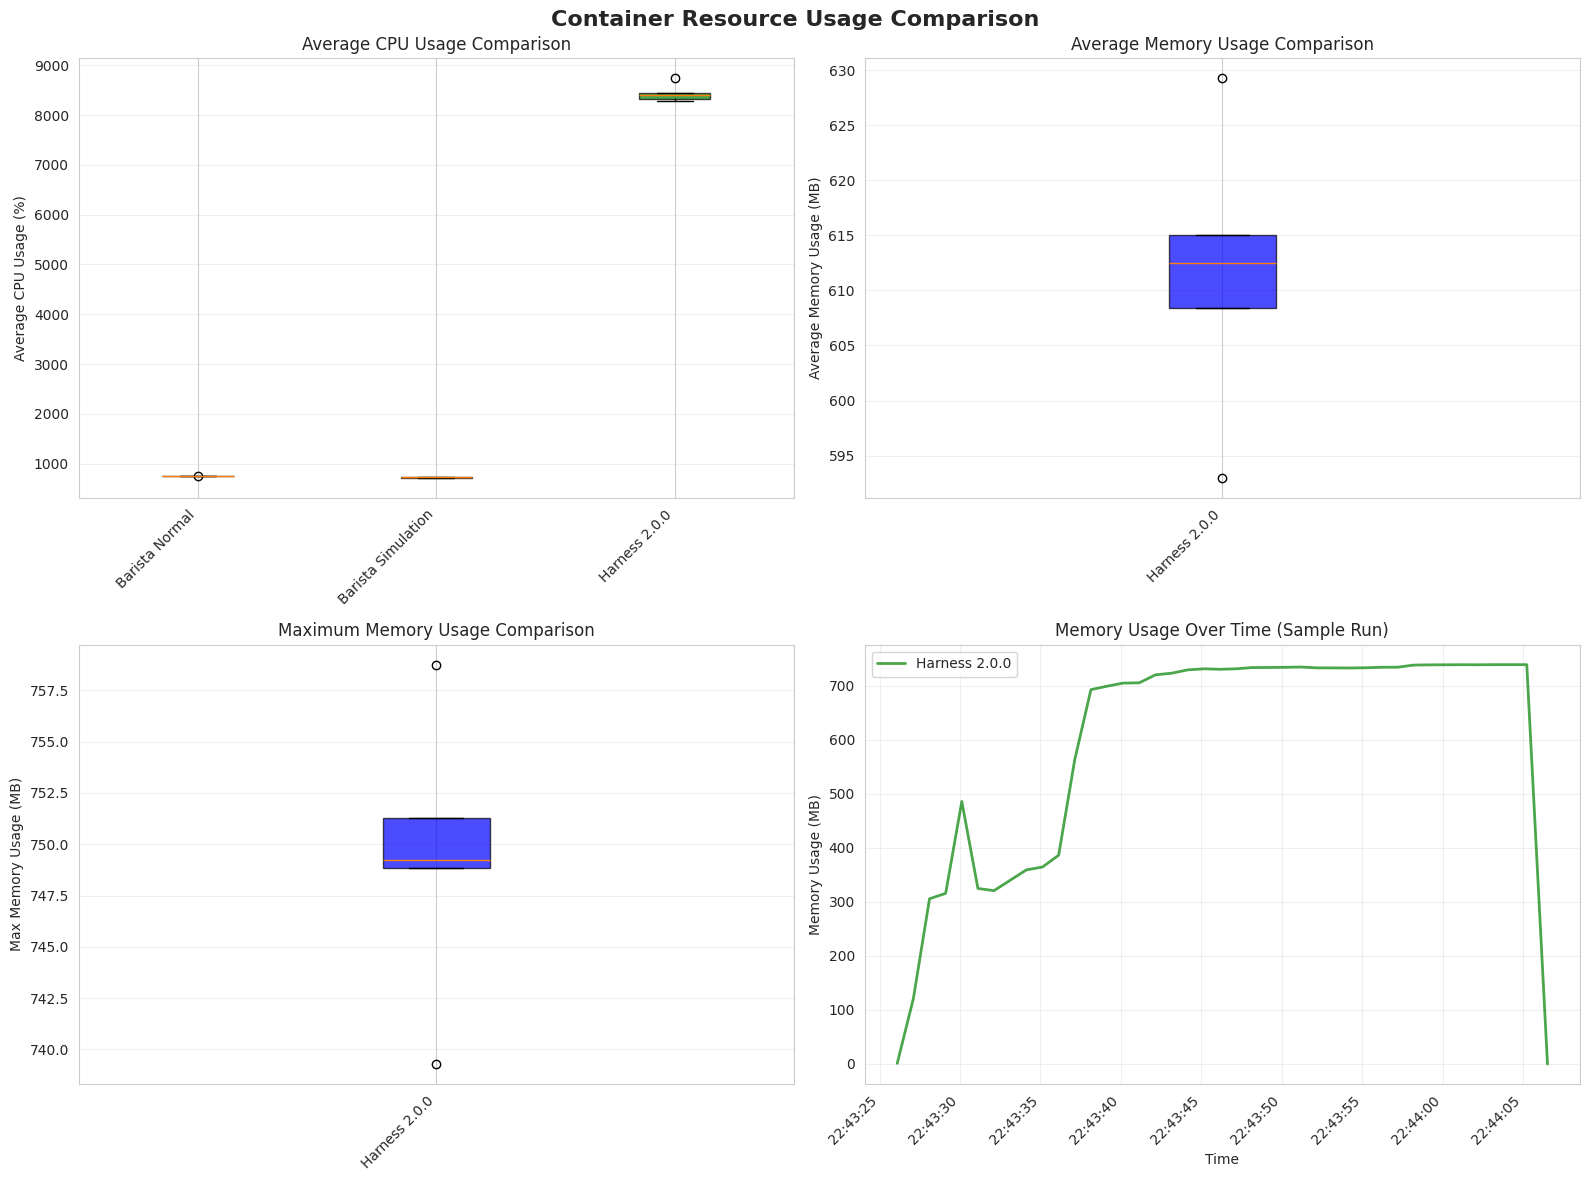


5. RSS (MEMORY) USAGE COMPARISON
--------------------------------------------------------------------------------

RSS Usage Summary:
                   Avg RSS (MB)            Max RSS (MB)            Min RSS (MB)          
                           mean        std         mean        std         mean       std
Source                                                                                   
Barista Normal      1010.189585  22.784925  1173.724219  40.793289   477.108594  5.955938
Barista Simulation   735.769104   7.425593   779.222656  13.186767   424.386719  4.362206
Harness 2.0.0        651.074196   7.619300   760.344531   6.389082   150.393750  8.961492


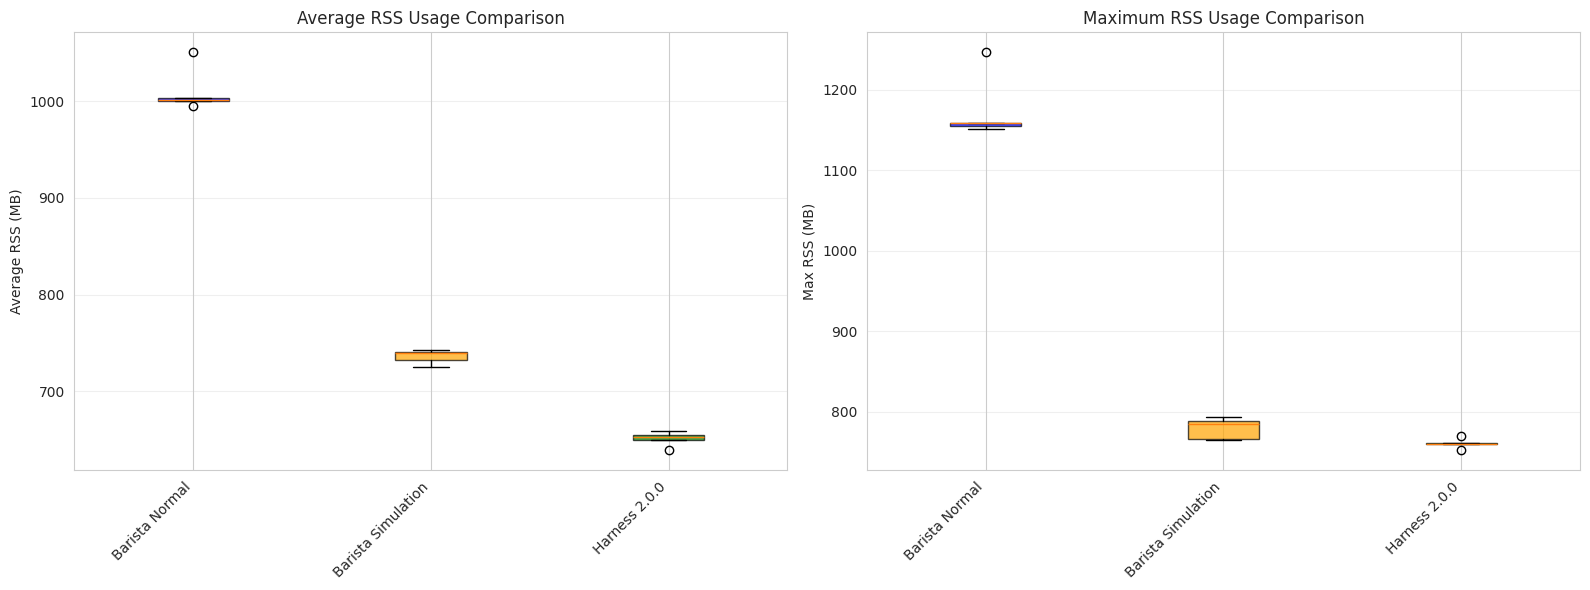


6. CPU USAGE COMPARISON
--------------------------------------------------------------------------------

CPU Usage Summary:
                    Avg CPU (%)               Max CPU (%)             Min CPU (%)           
                           mean         std          mean         std        mean        std
Source                                                                                      
Barista Normal       747.735188    4.047672    899.627428   23.124935   227.48301  43.916867
Barista Simulation   722.348722    3.172623    894.213109   19.524516   234.62934  41.334207
Harness 2.0.0       8437.841594  180.081226  13958.587120  173.976799     4.76288  10.650123


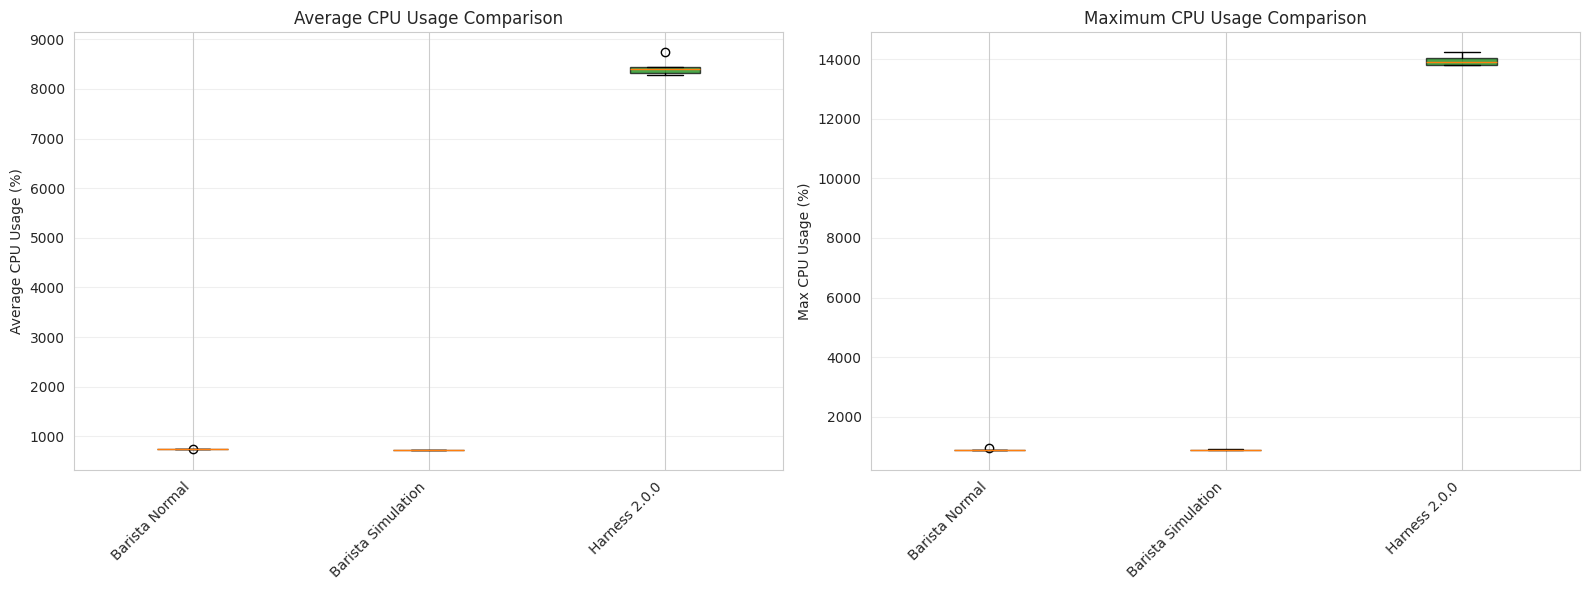


HYPOTHESIS 1 SUMMARY
Comparing Barista (normal), Barista (with simulation), and Harness 2.0.0
to verify that Harness 2.0.0 provides proper isolation similar to Barista.


In [253]:
# 4. Container Resource Usage Comparison
print("\n4. CONTAINER RESOURCE USAGE COMPARISON")
print("-" * 80)

# Process container stats
if len(harness_2_petclinic_jvm_g1gc_stats) > 0:
    # Calculate average CPU and memory per run
    harness_stats_summary = []
    for run in harness_2_petclinic_jvm_g1gc_stats['run'].unique():
        run_data = harness_2_petclinic_jvm_g1gc_stats[harness_2_petclinic_jvm_g1gc_stats['run'] == run]
        harness_stats_summary.append({
            'Source': 'Harness 2.0.0',
            'Run': run,
            'Avg CPU Usage (nanocores)': run_data['cpu_usage'].mean() if 'cpu_usage' in run_data.columns else 0,
            'Avg Memory (bytes)': run_data['memory_usage'].mean() if 'memory_usage' in run_data.columns else 0,
            'Max Memory (bytes)': run_data['memory_usage'].max() if 'memory_usage' in run_data.columns else 0
        })
    
    if harness_stats_summary:
        harness_stats_df = pd.DataFrame(harness_stats_summary)
        print("\nHarness 2.0.0 Container Stats:")
        print(harness_stats_df[['Source', 'Avg CPU Usage (nanocores)', 'Avg Memory (bytes)', 'Max Memory (bytes)']].describe().to_string())

# Process barista resource usage (normal)
if len(barista_petclinic_jvm_stats) > 0:
    barista_stats_summary = []
    for run in barista_petclinic_jvm_stats['run'].unique():
        run_data = barista_petclinic_jvm_stats[barista_petclinic_jvm_stats['run'] == run]
        # Barista uses different column names - check what's available
        if 'cpu' in run_data.columns:
            barista_stats_summary.append({
                'Source': 'Barista Normal',
                'Run': run,
                'Avg CPU Usage (%)': run_data['cpu'].mean(),
                'Avg RSS (MB)': run_data['rss'].mean() if 'rss' in run_data.columns else 0,
                'Max RSS (MB)': run_data['rss'].max() if 'rss' in run_data.columns else 0
            })
    
    if barista_stats_summary:
        barista_stats_df = pd.DataFrame(barista_stats_summary)
        print("\nBarista Normal Resource Usage:")
        print(barista_stats_df[['Source', 'Avg CPU Usage (%)', 'Avg RSS (MB)', 'Max RSS (MB)']].describe().to_string())

# Process barista resource usage (simulation)
if len(barista_petclinic_sim_jvm_stats) > 0:
    barista_sim_stats_summary = []
    for run in barista_petclinic_sim_jvm_stats['run'].unique():
        run_data = barista_petclinic_sim_jvm_stats[barista_petclinic_sim_jvm_stats['run'] == run]
        # Barista uses different column names - check what's available
        if 'cpu' in run_data.columns:
            barista_sim_stats_summary.append({
                'Source': 'Barista Simulation',
                'Run': run,
                'Avg CPU Usage (%)': run_data['cpu'].mean(),
                'Avg RSS (MB)': run_data['rss'].mean() if 'rss' in run_data.columns else 0,
                'Max RSS (MB)': run_data['rss'].max() if 'rss' in run_data.columns else 0
            })
    
    if barista_sim_stats_summary:
        barista_sim_stats_df = pd.DataFrame(barista_sim_stats_summary)
        print("\nBarista Simulation Resource Usage:")
        print(barista_sim_stats_df[['Source', 'Avg CPU Usage (%)', 'Avg RSS (MB)', 'Max RSS (MB)']].describe().to_string())

# Visualize resource usage if we have data
# Create comparison charts for all three sources
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Container Resource Usage Comparison', fontsize=16, fontweight='bold')

# 1. Average CPU Usage Comparison
ax1 = axes[0, 0]
cpu_comparison_data = []
cpu_labels = []

if len(barista_petclinic_jvm_stats) > 0 and 'cpu' in barista_petclinic_jvm_stats.columns:
    avg_cpu = barista_petclinic_jvm_stats.groupby('run')['cpu'].mean()
    cpu_comparison_data.append(flatten_to_1d(avg_cpu))
    cpu_labels.append('Barista Normal')

if len(barista_petclinic_sim_jvm_stats) > 0 and 'cpu' in barista_petclinic_sim_jvm_stats.columns:
    avg_cpu = barista_petclinic_sim_jvm_stats.groupby('run')['cpu'].mean()
    cpu_comparison_data.append(flatten_to_1d(avg_cpu))
    cpu_labels.append('Barista Simulation')

if len(harness_2_petclinic_jvm_g1gc_stats) > 0 and 'cpu_usage' in harness_2_petclinic_jvm_g1gc_stats.columns:
    avg_cpu = harness_2_petclinic_jvm_g1gc_stats.groupby('run')['cpu_usage'].mean() / 1e9 * 100  # Convert nanocores to percentage
    cpu_comparison_data.append(flatten_to_1d(avg_cpu))
    cpu_labels.append('Harness 2.0.0')

if cpu_comparison_data and len(cpu_comparison_data) > 0:
    bp = ax1.boxplot(cpu_comparison_data, labels=cpu_labels, patch_artist=True)
    colors = ['blue', 'orange', 'green']
    for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax1.set_ylabel('Average CPU Usage (%)')
    ax1.set_title('Average CPU Usage Comparison')
    ax1.grid(True, alpha=0.3, axis='y')
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 2. Average RSS/Memory Usage Comparison
ax2 = axes[0, 1]
rss_comparison_data = []
rss_labels = []

if len(barista_petclinic_jvm_stats) > 0 and 'rss' in barista_petclinic_jvm_stats.columns:
    avg_rss = barista_petclinic_jvm_stats.groupby('run')['rss'].mean()
    rss_comparison_data.append(flatten_to_1d(avg_rss))
    rss_labels.append('Barista Normal')

if len(barista_petclinic_sim_jvm_stats) > 0 and 'rss' in barista_petclinic_sim_jvm_stats.columns:
    avg_rss = barista_petclinic_sim_jvm_stats.groupby('run')['rss'].mean()
    rss_comparison_data.append(flatten_to_1d(avg_rss))
    rss_labels.append('Barista Simulation')

if len(harness_2_petclinic_jvm_g1gc_stats) > 0 and 'memory_usage' in harness_2_petclinic_jvm_g1gc_stats.columns:
    avg_mem = harness_2_petclinic_jvm_g1gc_stats.groupby('run')['memory_usage'].mean() / (1024*1024)  # Convert bytes to MB
    rss_comparison_data.append(flatten_to_1d(avg_mem))
    rss_labels.append('Harness 2.0.0')

if rss_comparison_data and len(rss_comparison_data) > 0:
    bp = ax2.boxplot(rss_comparison_data, labels=rss_labels, patch_artist=True)
    colors = ['blue', 'orange', 'green']
    for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax2.set_ylabel('Average Memory Usage (MB)')
    ax2.set_title('Average Memory Usage Comparison')
    ax2.grid(True, alpha=0.3, axis='y')
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 3. Max RSS/Memory Usage Comparison
ax3 = axes[1, 0]
max_rss_comparison_data = []
max_rss_labels = []

if len(barista_petclinic_jvm_stats) > 0 and 'rss' in barista_petclinic_jvm_stats.columns:
    max_rss = barista_petclinic_jvm_stats.groupby('run')['rss'].max()
    max_rss_comparison_data.append(flatten_to_1d(max_rss))
    max_rss_labels.append('Barista Normal')

if len(barista_petclinic_sim_jvm_stats) > 0 and 'rss' in barista_petclinic_sim_jvm_stats.columns:
    max_rss = barista_petclinic_sim_jvm_stats.groupby('run')['rss'].max()
    max_rss_comparison_data.append(flatten_to_1d(max_rss))
    max_rss_labels.append('Barista Simulation')

if len(harness_2_petclinic_jvm_g1gc_stats) > 0 and 'memory_usage' in harness_2_petclinic_jvm_g1gc_stats.columns:
    max_mem = harness_2_petclinic_jvm_g1gc_stats.groupby('run')['memory_usage'].max() / (1024*1024)  # Convert bytes to MB
    max_rss_comparison_data.append(flatten_to_1d(max_mem))
    max_rss_labels.append('Harness 2.0.0')

if max_rss_comparison_data and len(max_rss_comparison_data) > 0:
    bp = ax3.boxplot(max_rss_comparison_data, labels=max_rss_labels, patch_artist=True)
    colors = ['blue', 'orange', 'green']
    for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax3.set_ylabel('Max Memory Usage (MB)')
    ax3.set_title('Maximum Memory Usage Comparison')
    ax3.grid(True, alpha=0.3, axis='y')
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 4. Memory usage over time for a sample run (if available)
ax4 = axes[1, 1]
if len(harness_2_petclinic_jvm_g1gc_stats) > 0 and 'memory_usage' in harness_2_petclinic_jvm_g1gc_stats.columns and 'timestamp' in harness_2_petclinic_jvm_g1gc_stats.columns:
    sample_run = harness_2_petclinic_jvm_g1gc_stats['run'].iloc[0]
    sample_data = harness_2_petclinic_jvm_g1gc_stats[harness_2_petclinic_jvm_g1gc_stats['run'] == sample_run]
    if len(sample_data) > 0:
        sample_data = sample_data.sort_values('timestamp')
        ax4.plot(sample_data['timestamp'], sample_data['memory_usage'] / (1024*1024), 
                label='Harness 2.0.0', color='green', alpha=0.7, linewidth=2)
        ax4.set_xlabel('Time')
        ax4.set_ylabel('Memory Usage (MB)')
        ax4.set_title('Memory Usage Over Time (Sample Run)')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
        plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right')
    else:
        ax4.text(0.5, 0.5, 'No time series data available', 
                ha='center', va='center', transform=ax4.transAxes)
        ax4.set_title('Memory Usage Over Time')
else:
    ax4.text(0.5, 0.5, 'No time series data available', 
            ha='center', va='center', transform=ax4.transAxes)
    ax4.set_title('Memory Usage Over Time')

plt.tight_layout()
plt.show()

# 5. RSS (Memory) Usage Comparison
print("\n5. RSS (MEMORY) USAGE COMPARISON")
print("-" * 80)

rss_data = []

# Barista Normal RSS
if len(barista_petclinic_jvm_stats) > 0 and 'rss_mb' in barista_petclinic_jvm_stats.columns:
    for run in barista_petclinic_jvm_stats['run'].unique():
        run_data = barista_petclinic_jvm_stats[barista_petclinic_jvm_stats['run'] == run]
        rss_data.append({
            'Source': 'Barista Normal',
            'Run': run,
            'Avg RSS (MB)': run_data['rss_mb'].mean(),
            'Max RSS (MB)': run_data['rss_mb'].max(),
            'Min RSS (MB)': run_data['rss_mb'].min()
        })

# Barista Simulation RSS
if len(barista_petclinic_sim_jvm_stats) > 0 and 'rss_mb' in barista_petclinic_sim_jvm_stats.columns:
    for run in barista_petclinic_sim_jvm_stats['run'].unique():
        run_data = barista_petclinic_sim_jvm_stats[barista_petclinic_sim_jvm_stats['run'] == run]
        rss_data.append({
            'Source': 'Barista Simulation',
            'Run': run,
            'Avg RSS (MB)': run_data['rss_mb'].mean(),
            'Max RSS (MB)': run_data['rss_mb'].max(),
            'Min RSS (MB)': run_data['rss_mb'].min()
        })

# Harness 2.0.0 RSS
if len(harness_2_petclinic_jvm_g1gc_rss) > 0:
    for run in harness_2_petclinic_jvm_g1gc_rss['run'].unique():
        run_data = harness_2_petclinic_jvm_g1gc_rss[harness_2_petclinic_jvm_g1gc_rss['run'] == run]
        rss_data.append({
            'Source': 'Harness 2.0.0',
            'Run': run,
            'Avg RSS (MB)': run_data['rss_mb'].mean(),
            'Max RSS (MB)': run_data['rss_mb'].max(),
            'Min RSS (MB)': run_data['rss_mb'].min()
        })

if rss_data:
    rss_df = pd.DataFrame(rss_data)
    print("\nRSS Usage Summary:")
    summary = rss_df.groupby('Source')[['Avg RSS (MB)', 'Max RSS (MB)', 'Min RSS (MB)']].agg(['mean', 'std'])
    print(summary.to_string())
    
    # Visualize RSS usage
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Average RSS
    ax1 = axes[0]
    sources = rss_df['Source'].unique()
    data_to_plot = [rss_df[rss_df['Source'] == s]['Avg RSS (MB)'].values for s in sources]
    if data_to_plot:
        bp = ax1.boxplot(data_to_plot, labels=sources, patch_artist=True)
        colors = ['blue', 'orange', 'green']
        for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        ax1.set_ylabel('Average RSS (MB)')
        ax1.set_title('Average RSS Usage Comparison')
        ax1.grid(True, alpha=0.3, axis='y')
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Max RSS
    ax2 = axes[1]
    data_to_plot = [rss_df[rss_df['Source'] == s]['Max RSS (MB)'].values for s in sources]
    if data_to_plot:
        bp = ax2.boxplot(data_to_plot, labels=sources, patch_artist=True)
        colors = ['blue', 'orange', 'green']
        for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        ax2.set_ylabel('Max RSS (MB)')
        ax2.set_title('Maximum RSS Usage Comparison')
        ax2.grid(True, alpha=0.3, axis='y')
        plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
else:
    print("No RSS data available")

# 6. CPU Usage Comparison
print("\n6. CPU USAGE COMPARISON")
print("-" * 80)

cpu_data = []

# Barista Normal CPU
if len(barista_petclinic_jvm_stats) > 0 and 'cpu' in barista_petclinic_jvm_stats.columns:
    for run in barista_petclinic_jvm_stats['run'].unique():
        run_data = barista_petclinic_jvm_stats[barista_petclinic_jvm_stats['run'] == run]
        cpu_data.append({
            'Source': 'Barista Normal',
            'Run': run,
            'Avg CPU (%)': run_data['cpu'].mean(),
            'Max CPU (%)': run_data['cpu'].max(),
            'Min CPU (%)': run_data['cpu'].min()
        })

# Barista Simulation CPU
if len(barista_petclinic_sim_jvm_stats) > 0 and 'cpu' in barista_petclinic_sim_jvm_stats.columns:
    for run in barista_petclinic_sim_jvm_stats['run'].unique():
        run_data = barista_petclinic_sim_jvm_stats[barista_petclinic_sim_jvm_stats['run'] == run]
        cpu_data.append({
            'Source': 'Barista Simulation',
            'Run': run,
            'Avg CPU (%)': run_data['cpu'].mean(),
            'Max CPU (%)': run_data['cpu'].max(),
            'Min CPU (%)': run_data['cpu'].min()
        })

# Harness 2.0.0 CPU (from container stats - convert nanocores to percentage/cores)
if len(harness_2_petclinic_jvm_g1gc_stats) > 0 and 'cpu_usage' in harness_2_petclinic_jvm_g1gc_stats.columns:
    for run in harness_2_petclinic_jvm_g1gc_stats['run'].unique():
        run_data = harness_2_petclinic_jvm_g1gc_stats[harness_2_petclinic_jvm_g1gc_stats['run'] == run]
        # Convert nanocores to cores (assuming 4 cores = 400% CPU)
        cpu_cores = run_data['cpu_usage'] / 1e9  # Convert nanocores to cores
        cpu_data.append({
            'Source': 'Harness 2.0.0',
            'Run': run,
            'Avg CPU (%)': cpu_cores.mean() * 100,  # Convert to percentage (1 core = 100%)
            'Max CPU (%)': cpu_cores.max() * 100,
            'Min CPU (%)': cpu_cores.min() * 100
        })

if cpu_data:
    cpu_df = pd.DataFrame(cpu_data)
    print("\nCPU Usage Summary:")
    summary = cpu_df.groupby('Source')[['Avg CPU (%)', 'Max CPU (%)', 'Min CPU (%)']].agg(['mean', 'std'])
    print(summary.to_string())
    
    # Visualize CPU usage
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Average CPU
    ax1 = axes[0]
    sources = cpu_df['Source'].unique()
    data_to_plot = [cpu_df[cpu_df['Source'] == s]['Avg CPU (%)'].values for s in sources]
    if data_to_plot:
        bp = ax1.boxplot(data_to_plot, labels=sources, patch_artist=True)
        colors = ['blue', 'orange', 'green']
        for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        ax1.set_ylabel('Average CPU Usage (%)')
        ax1.set_title('Average CPU Usage Comparison')
        ax1.grid(True, alpha=0.3, axis='y')
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Max CPU
    ax2 = axes[1]
    data_to_plot = [cpu_df[cpu_df['Source'] == s]['Max CPU (%)'].values for s in sources]
    if data_to_plot:
        bp = ax2.boxplot(data_to_plot, labels=sources, patch_artist=True)
        colors = ['blue', 'orange', 'green']
        for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        ax2.set_ylabel('Max CPU Usage (%)')
        ax2.set_title('Maximum CPU Usage Comparison')
        ax2.grid(True, alpha=0.3, axis='y')
        plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
else:
    print("No CPU data available")

print("\n" + "="*80)
print("HYPOTHESIS 1 SUMMARY")
print("="*80)
print("Comparing Barista (normal), Barista (with simulation), and Harness 2.0.0")
print("to verify that Harness 2.0.0 provides proper isolation similar to Barista.")
print("="*80)



7. COMPREHENSIVE ISOLATION COMPARISON - PETCLINIC
--------------------------------------------------------------------------------

7. COMPREHENSIVE ISOLATION COMPARISON - SHOPCART
--------------------------------------------------------------------------------

COMPREHENSIVE COMPARISON: Petclinic


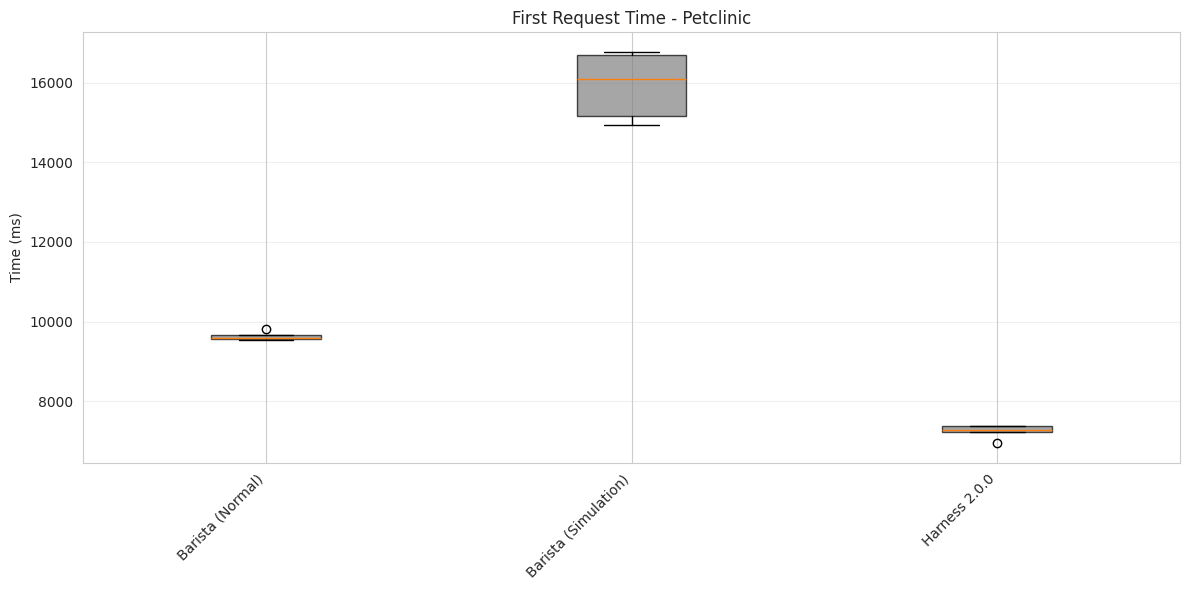

Debug: Checking column names in harness dataframes:
  Harness 2.0.0 G1GC columns starting with 'p': []
  Harness 2.0.0 Shenandoah columns starting with 'p': []
  Harness 1.0.0 G1GC columns starting with 'p': []



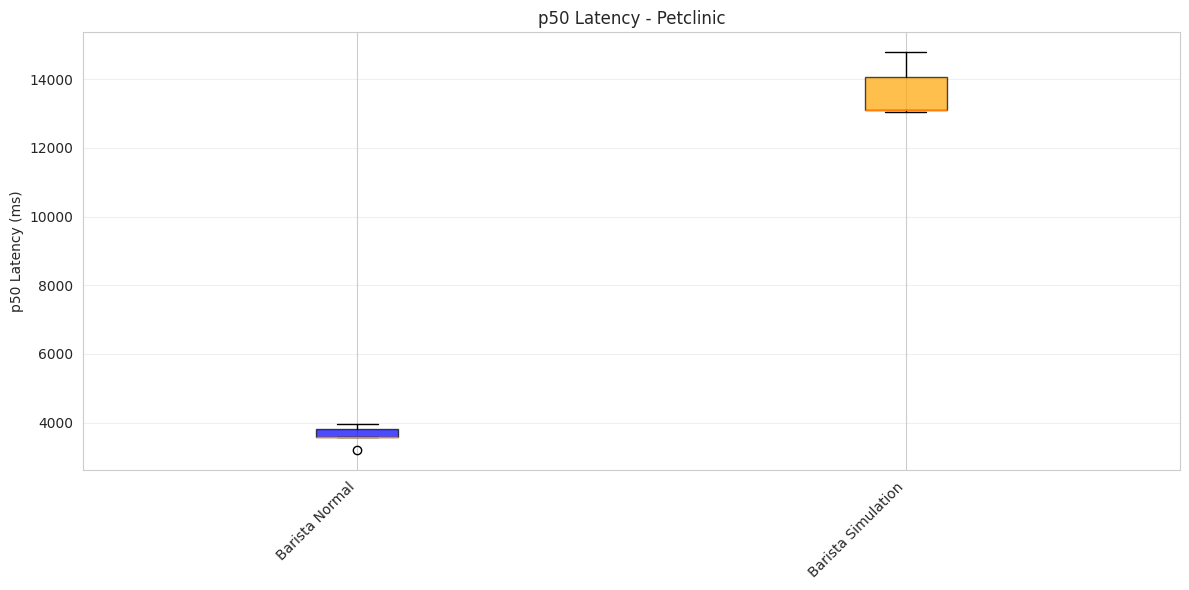

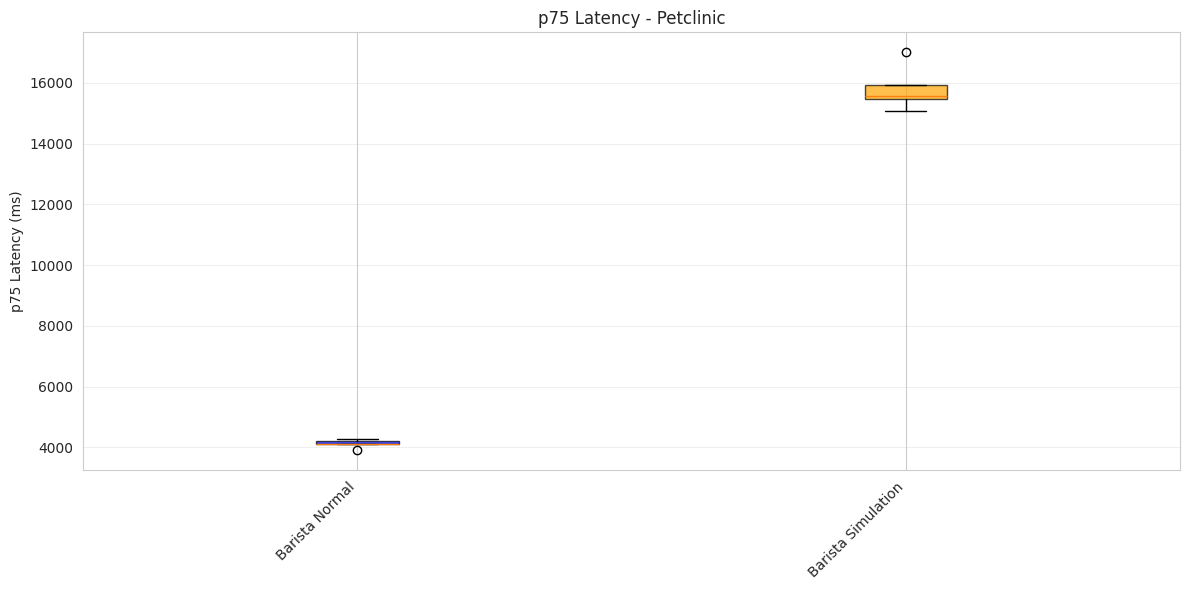

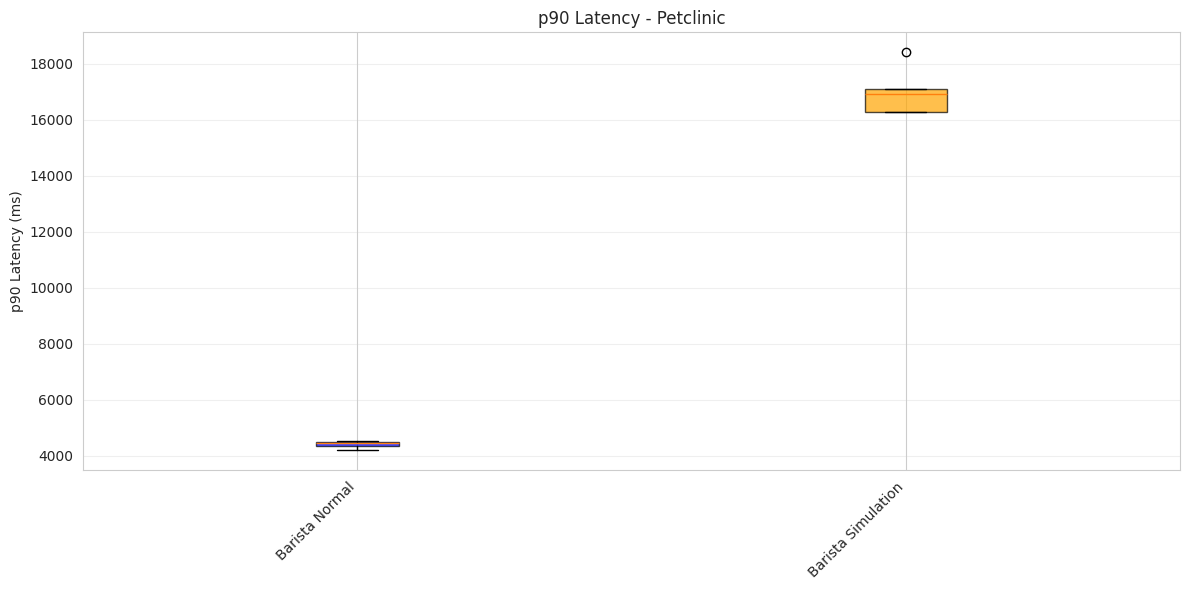

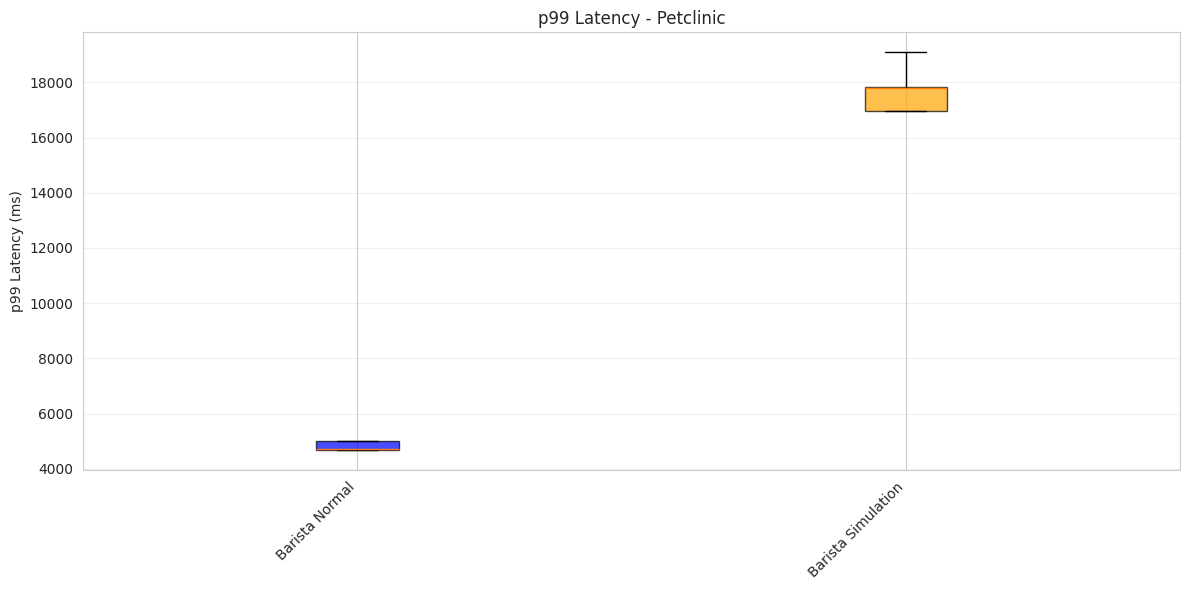

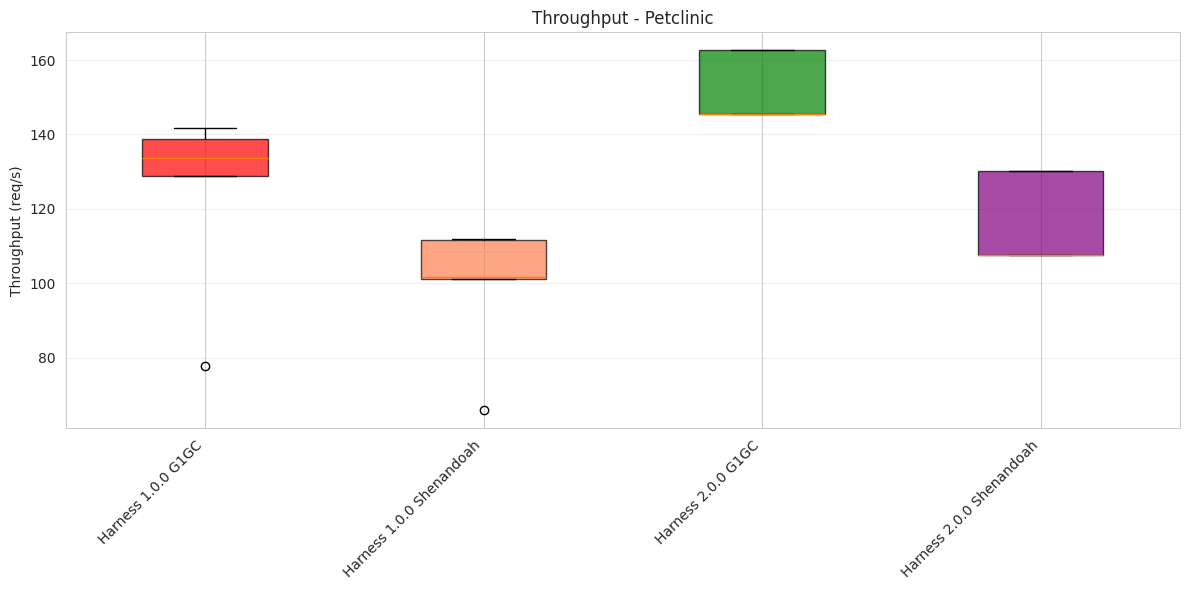

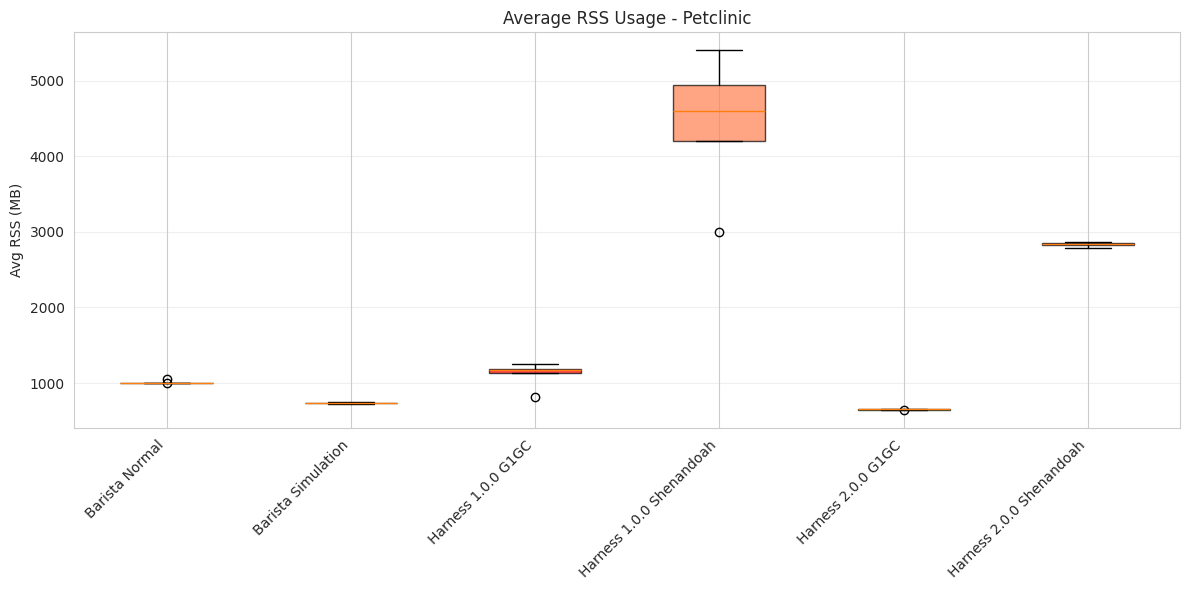

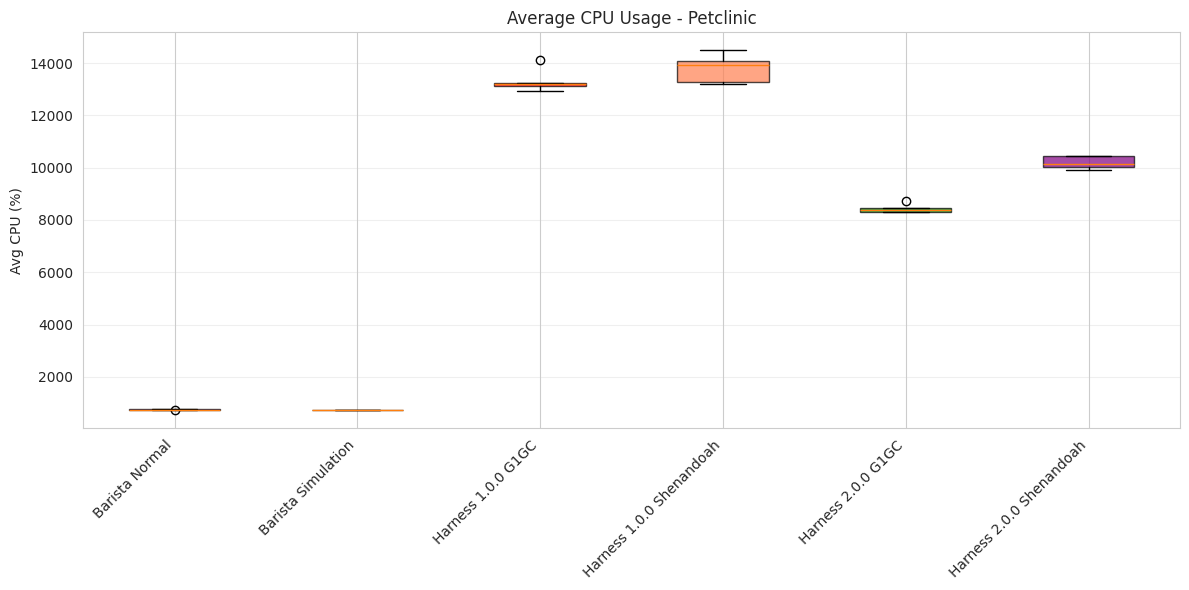

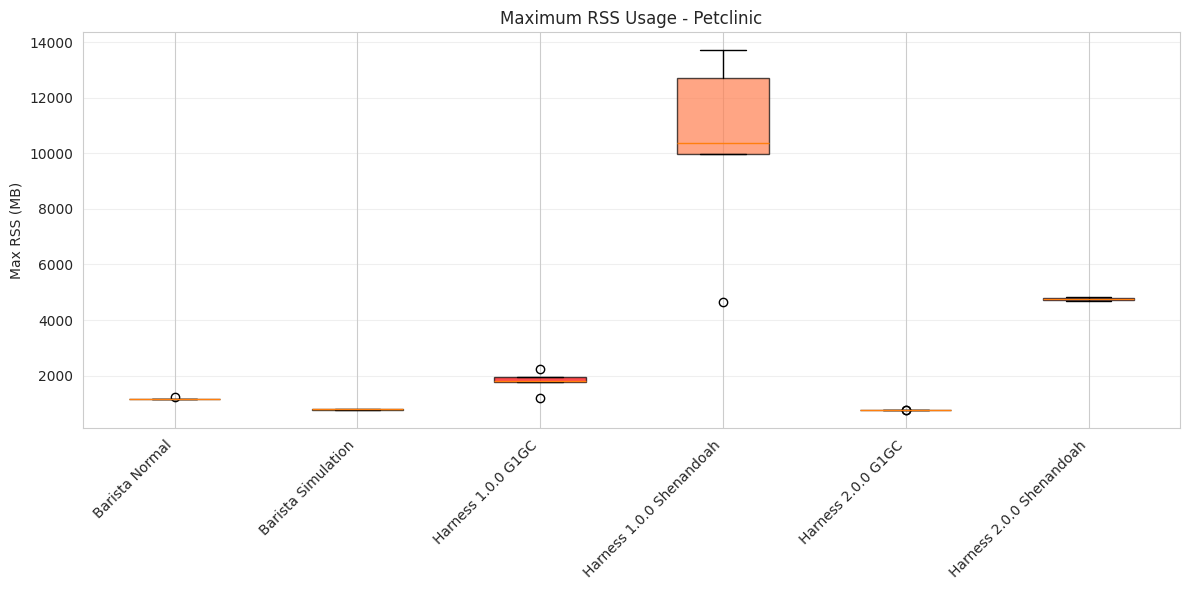


COMPREHENSIVE COMPARISON: Shopcart


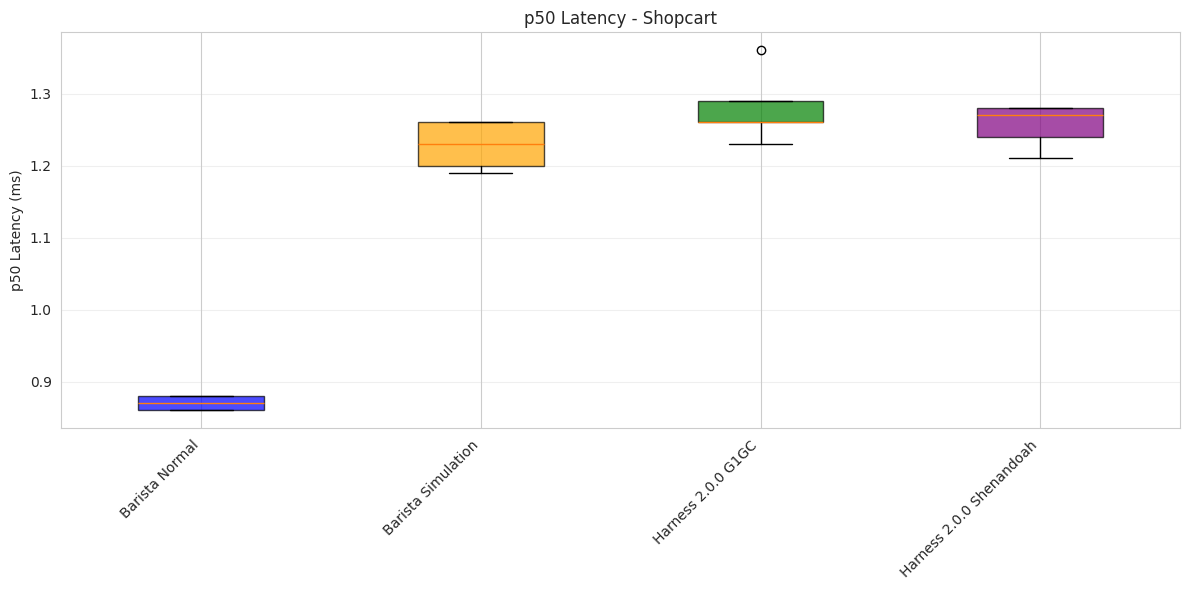

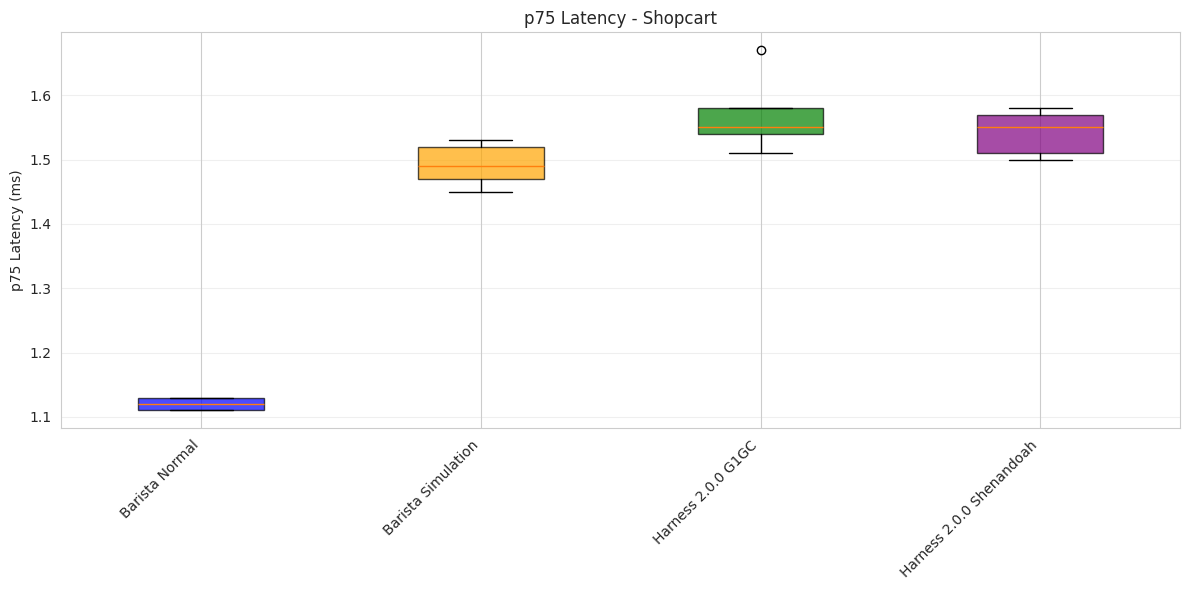

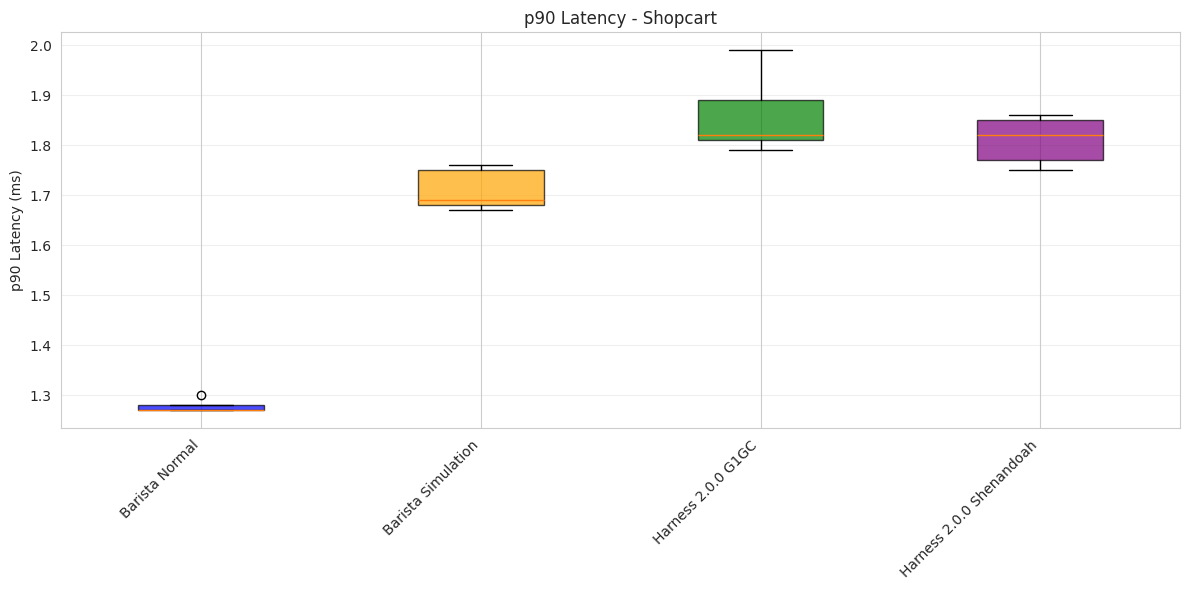

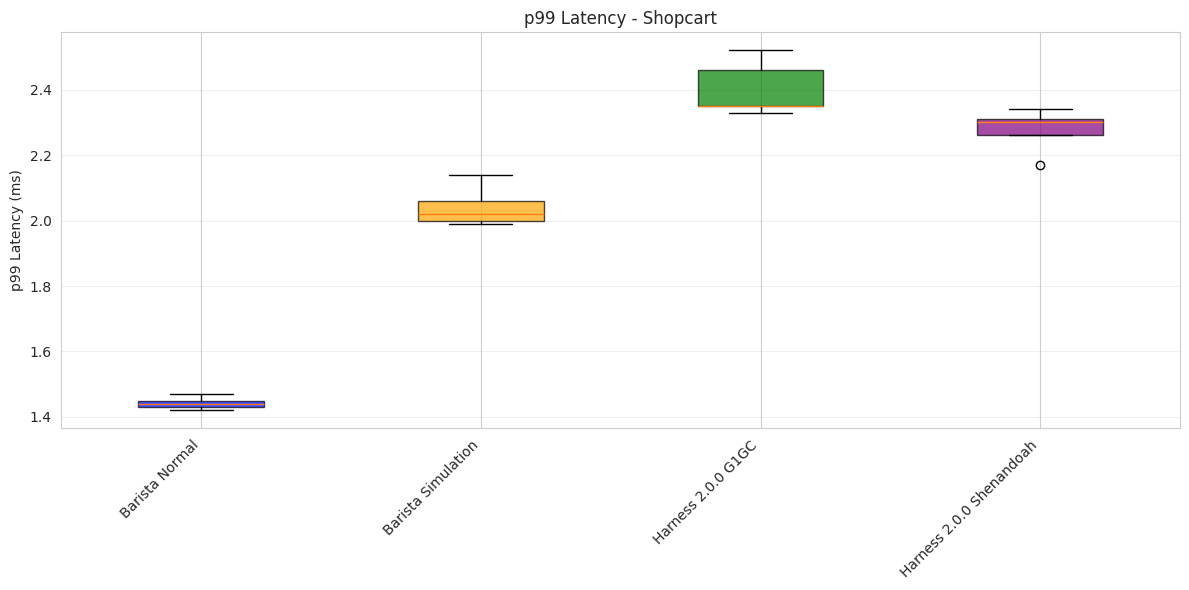

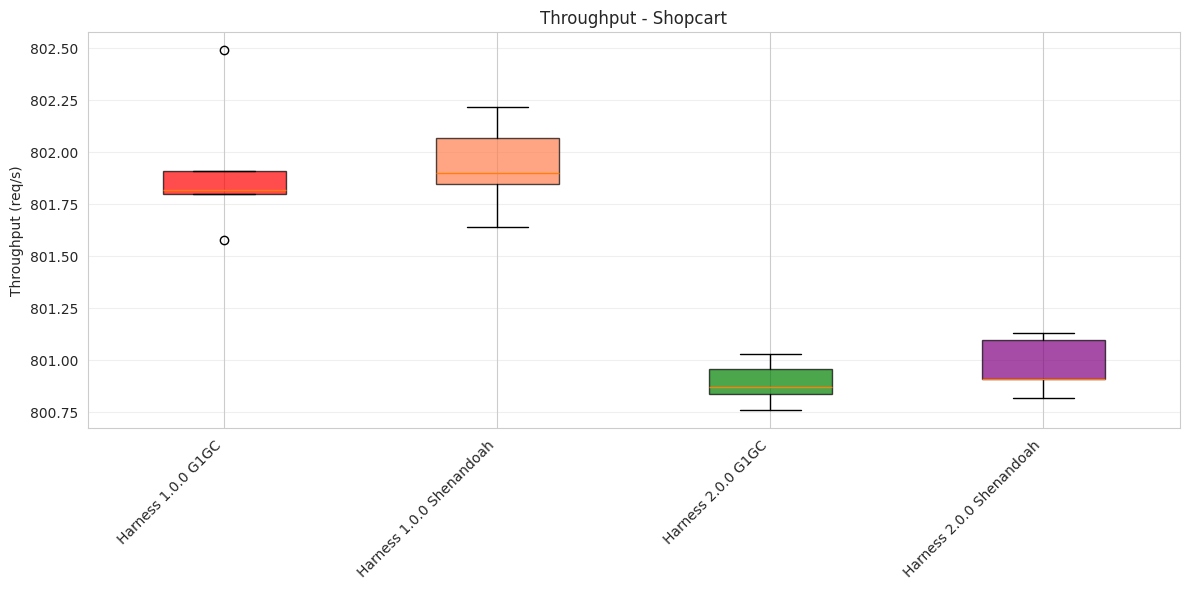

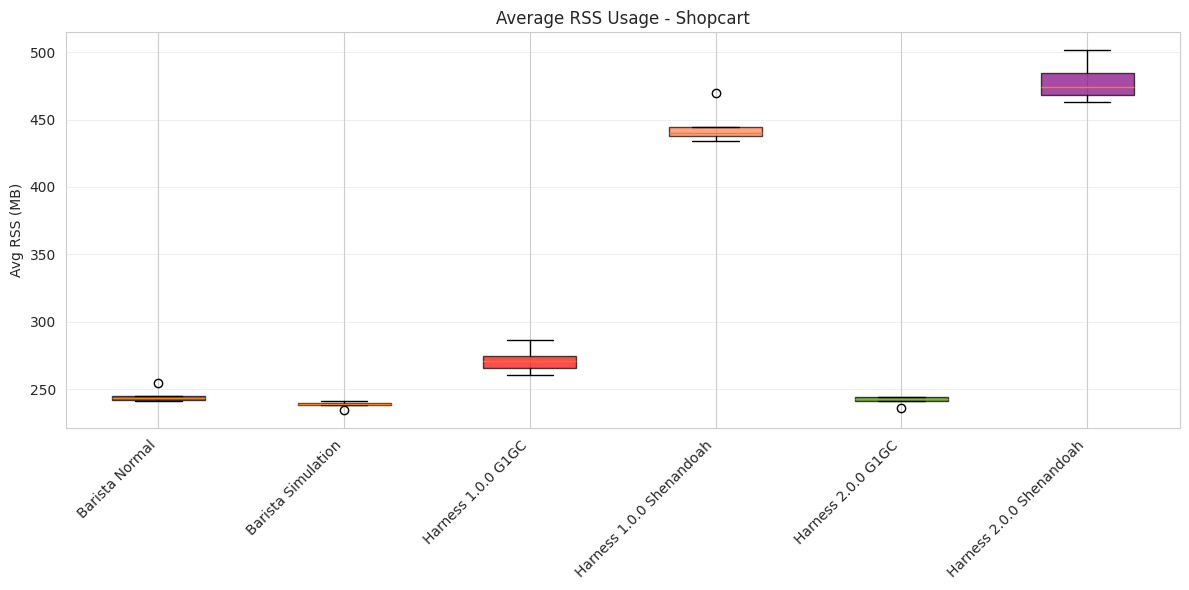

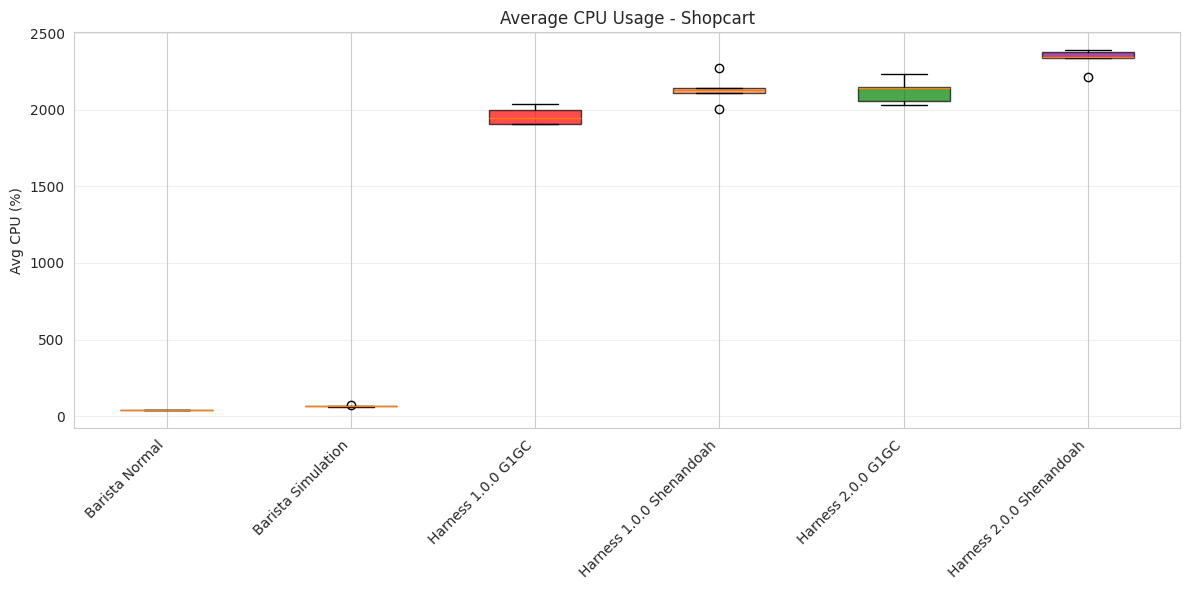

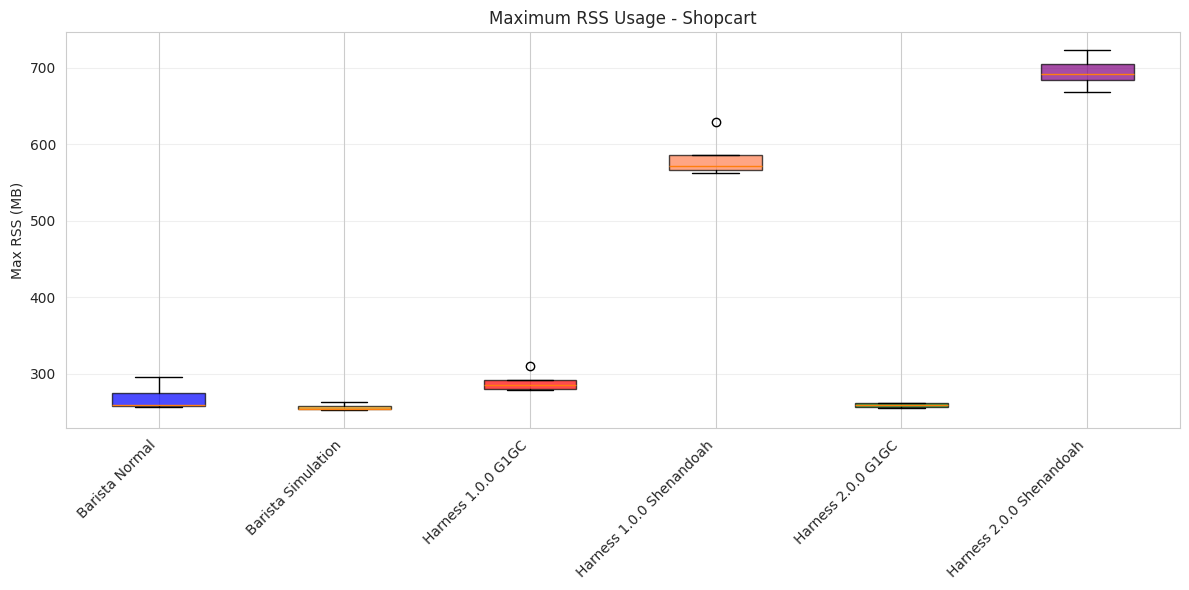


MEDIA MICROSERVICES COMPARISON

COMPREHENSIVE COMPARISON: Media


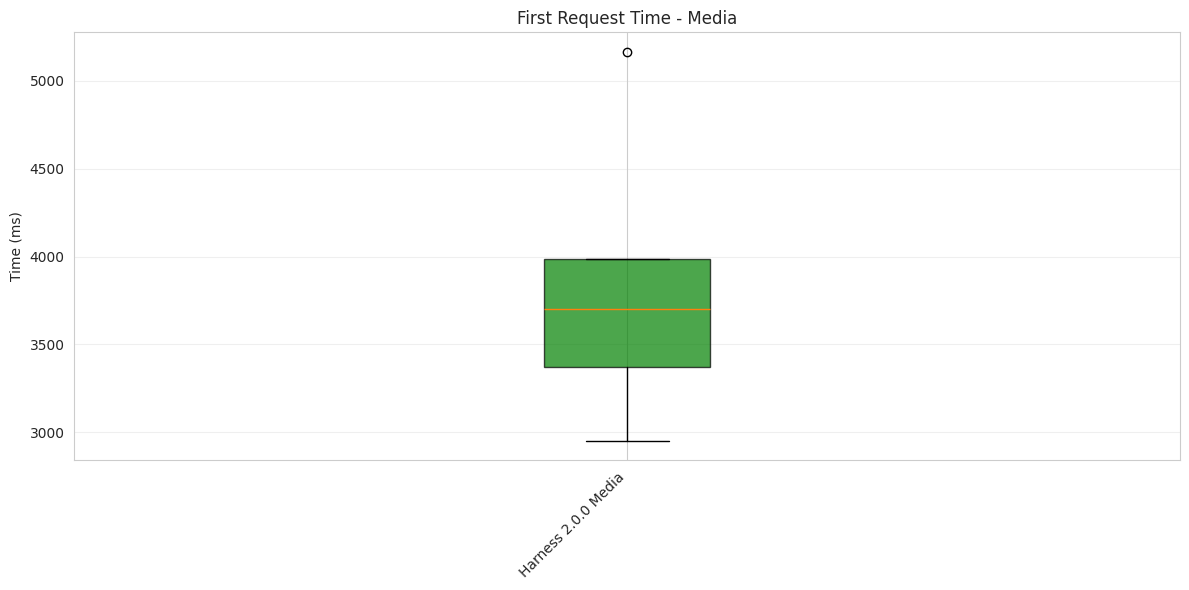

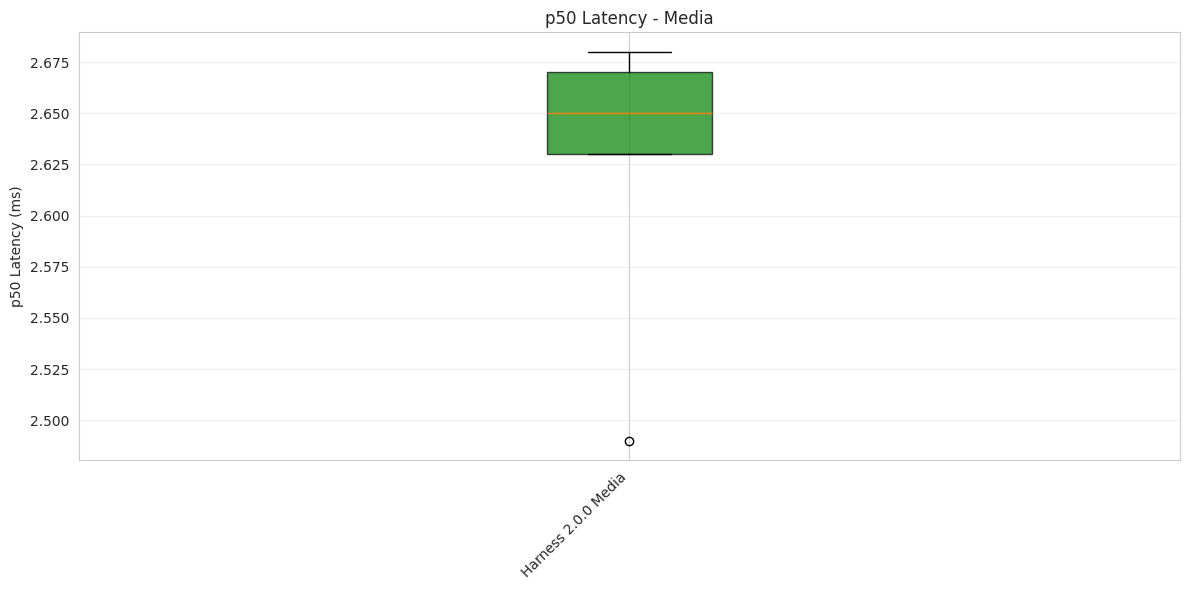

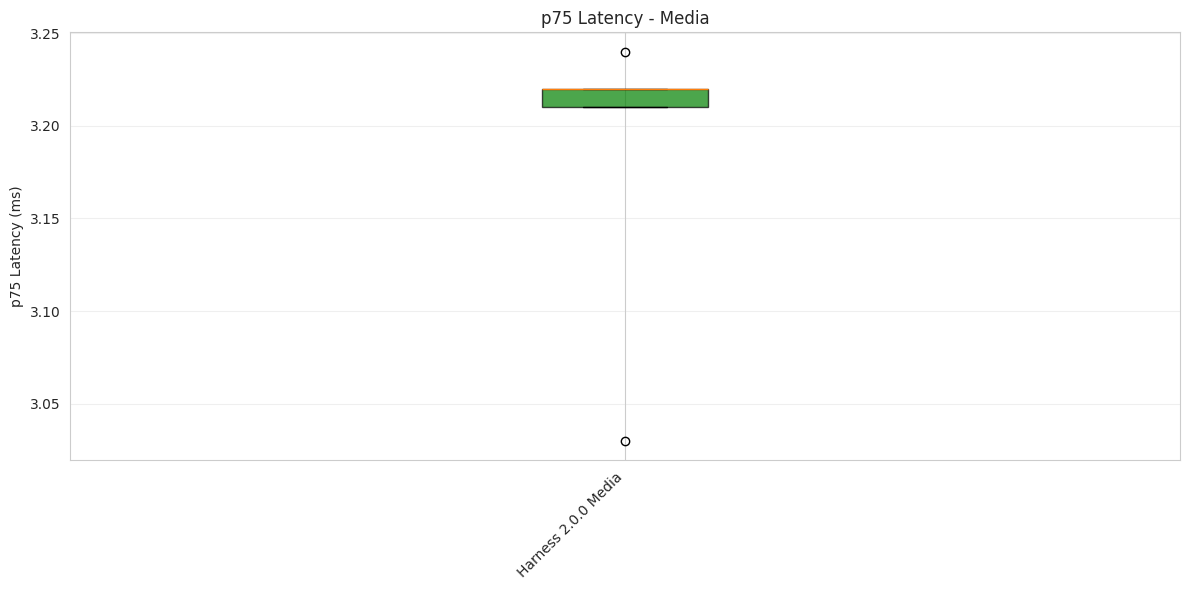

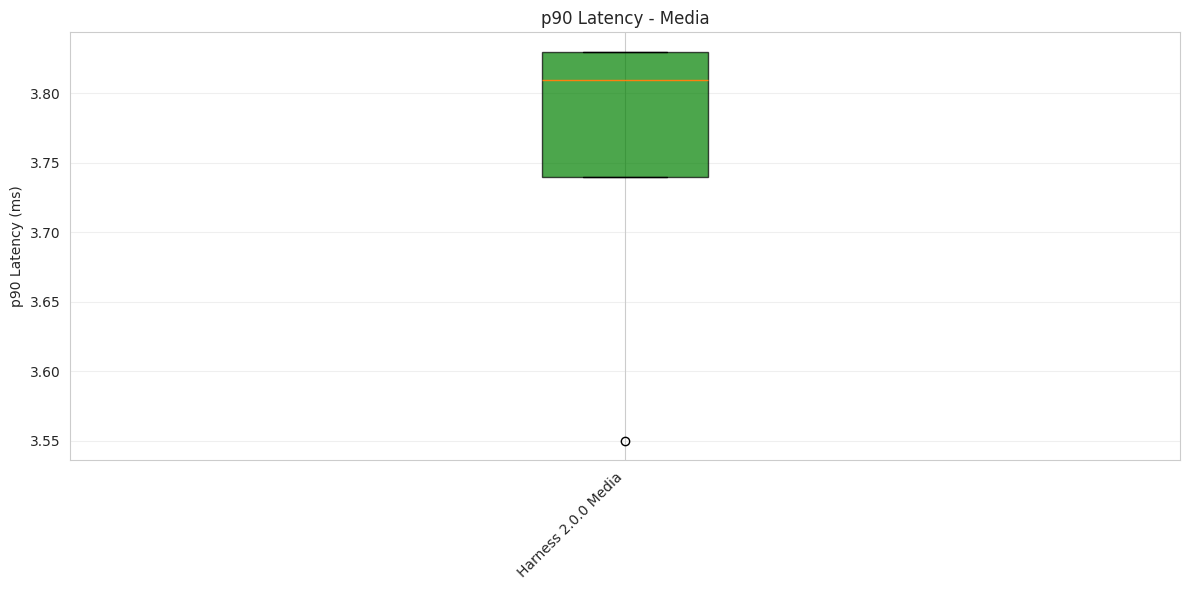

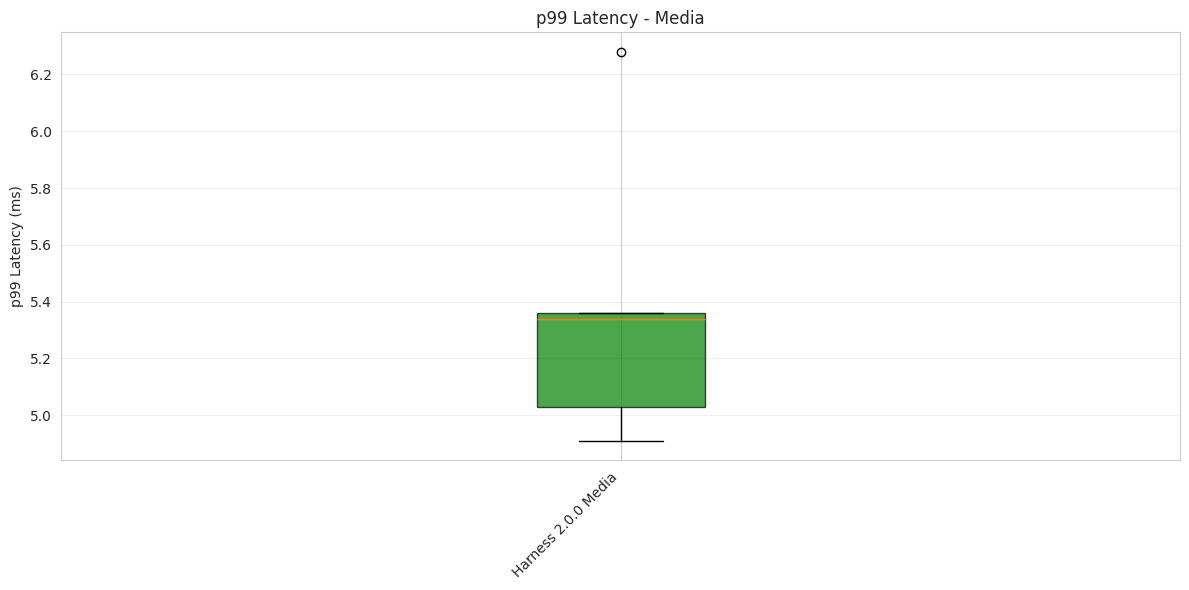

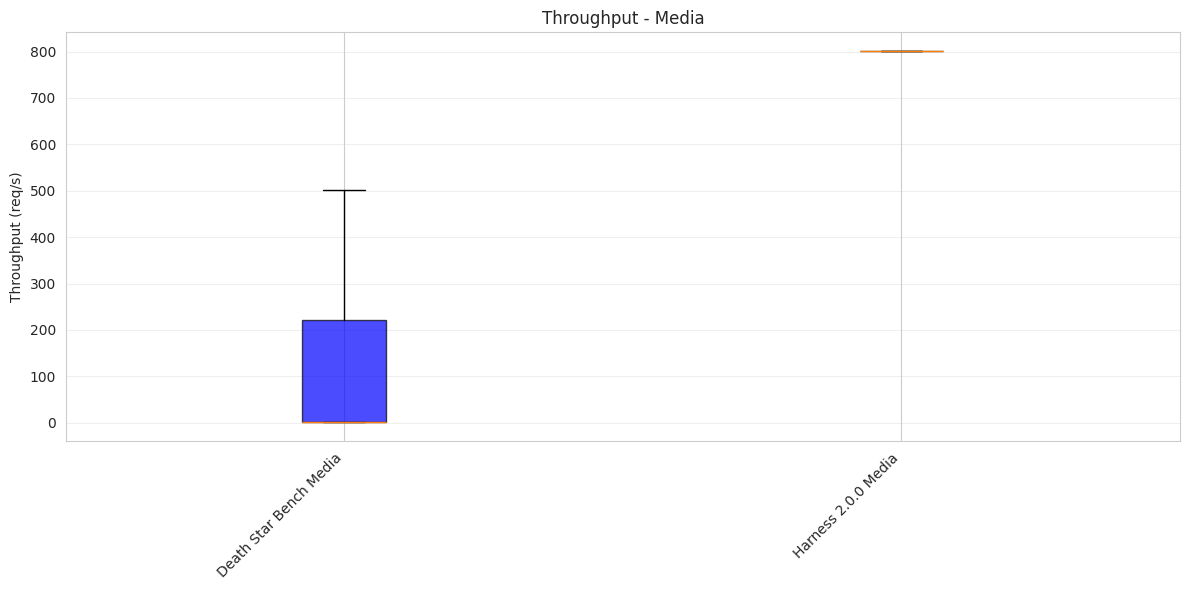

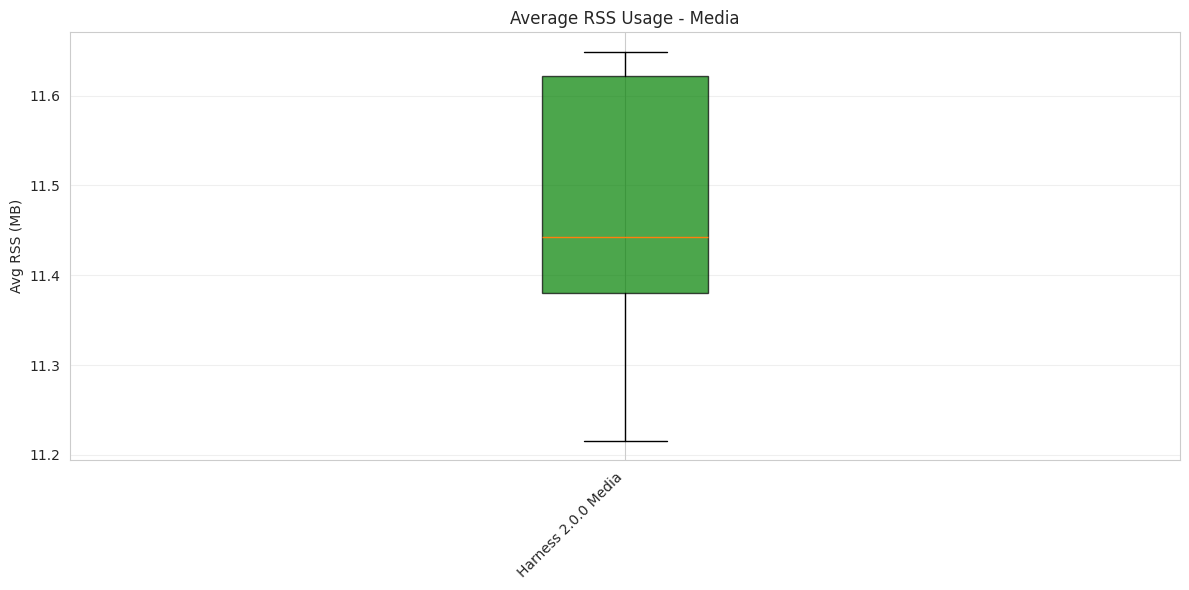

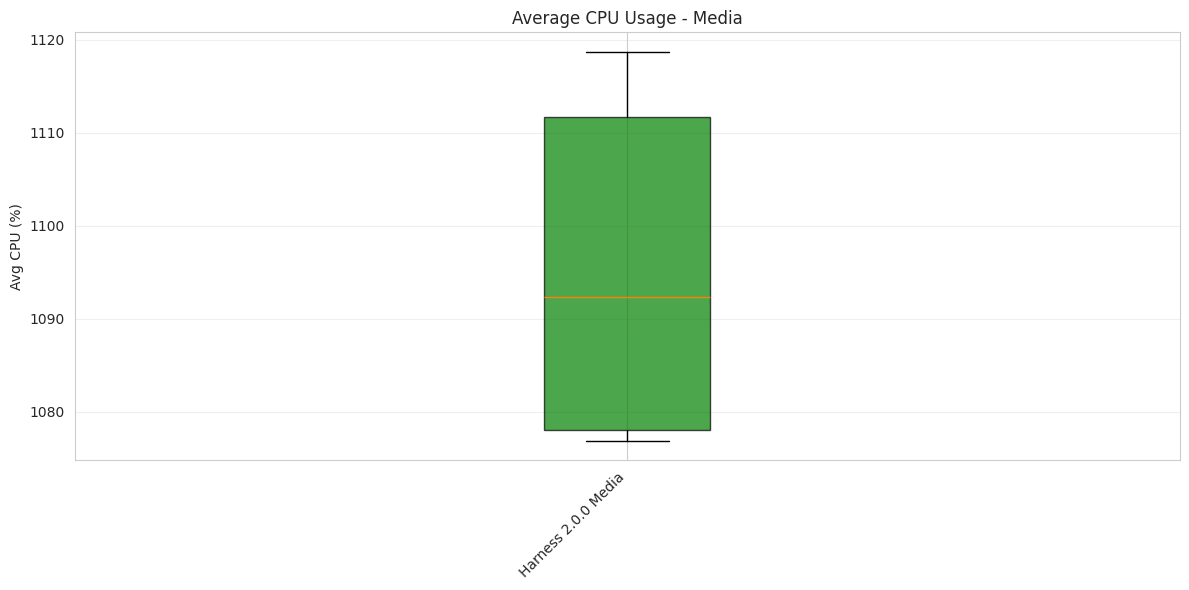

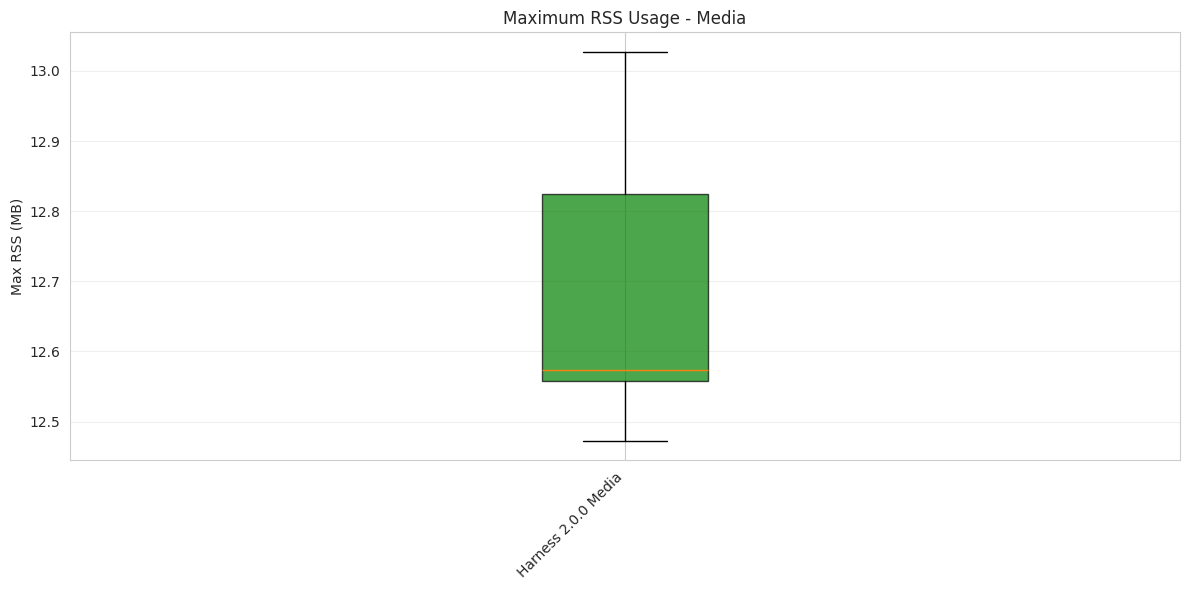

In [254]:
# Additional comprehensive comparison visualization
# Separate analysis for Petclinic and Shopcart

print("\n7. COMPREHENSIVE ISOLATION COMPARISON - PETCLINIC")
print("-" * 80)

# Define datasets for Petclinic visualization - include all GC variants
petclinic_datasets = [
    (barista_petclinic_jvm, 'Barista Normal', 'blue'),
    (barista_petclinic_sim_jvm, 'Barista Simulation', 'orange'),
    (harness_1_petclinic_jvm_g1gc, 'Harness 1.0.0 G1GC', 'red'),
    (harness_1_petclinic_jvm_shenandoah, 'Harness 1.0.0 Shenandoah', 'coral'),
    (harness_2_petclinic_jvm_g1gc, 'Harness 2.0.0 G1GC', 'green'),
    (harness_2_petclinic_jvm_shenandoah, 'Harness 2.0.0 Shenandoah', 'purple'),
]

print("\n7. COMPREHENSIVE ISOLATION COMPARISON - SHOPCART")
print("-" * 80)

# Define datasets for Shopcart visualization - include all GC variants
shopcart_datasets = [
    (barista_shopcart_jvm, 'Barista Normal', 'blue'),
    (barista_shopcart_sim_jvm, 'Barista Simulation', 'orange'),
    (harness_1_shopcart_jvm_g1gc, 'Harness 1.0.0 G1GC', 'red'),
    (harness_1_shopcart_jvm_shenandoah, 'Harness 1.0.0 Shenandoah', 'coral'),
    (harness_2_shopcart_jvm_g1gc, 'Harness 2.0.0 G1GC', 'green'),
    (harness_2_shopcart_jvm_shenandoah, 'Harness 2.0.0 Shenandoah', 'purple'),
]

# Use petclinic datasets for the main visualization (will create separate function for shopcart)
datasets = petclinic_datasets

def create_comprehensive_comparison(datasets, app_name, first_req_data=None, rss_data_dict=None, cpu_data_dict=None):
    """Create comprehensive comparison visualization for a given application
    
    Args:
        datasets: List of (dataframe, label, color) tuples
        app_name: Name of the application (e.g., 'Petclinic', 'Shopcart')
        first_req_data: Optional list of first request data dictionaries
        rss_data_dict: Optional dict mapping dataset labels to RSS dataframes
        cpu_data_dict: Optional dict mapping dataset labels to CPU dataframes
    """
    print(f"\n{'='*80}")
    print(f"COMPREHENSIVE COMPARISON: {app_name}")
    print(f"{'='*80}")
    
    # Collect RSS data from available sources
    rss_data_list = []
    if rss_data_dict:
        for label, rss_df in rss_data_dict.items():
            if len(rss_df) > 0:
                if 'rss_mb' in rss_df.columns:
                    for run in rss_df['run'].unique():
                        run_data = rss_df[rss_df['run'] == run]
                        rss_values = pd.to_numeric(run_data['rss_mb'], errors='coerce').dropna()
                        if len(rss_values) > 0:
                            rss_data_list.append({
                                'Source': label,
                                'Run': run,
                                'Avg RSS (MB)': rss_values.mean(),
                                'Max RSS (MB)': rss_values.max(),
                                'Min RSS (MB)': rss_values.min()
                            })
                elif 'rss' in rss_df.columns:
                    for run in rss_df['run'].unique():
                        run_data = rss_df[rss_df['run'] == run]
                        rss_values = pd.to_numeric(run_data['rss'], errors='coerce').dropna()
                        if len(rss_values) > 0:
                            rss_data_list.append({
                                'Source': label,
                                'Run': run,
                                'Avg RSS (MB)': rss_values.mean(),
                                'Max RSS (MB)': rss_values.max(),
                                'Min RSS (MB)': rss_values.min()
                            })
    
    # Collect CPU data from available sources
    cpu_data_list = []
    if cpu_data_dict:
        for label, cpu_df in cpu_data_dict.items():
            if len(cpu_df) > 0:
                if 'cpu' in cpu_df.columns:
                    # Barista uses percentage directly
                    for run in cpu_df['run'].unique():
                        run_data = cpu_df[cpu_df['run'] == run]
                        cpu_values = pd.to_numeric(run_data['cpu'], errors='coerce').dropna()
                        if len(cpu_values) > 0:
                            cpu_data_list.append({
                                'Source': label,
                                'Run': run,
                                'Avg CPU (%)': cpu_values.mean(),
                                'Max CPU (%)': cpu_values.max(),
                                'Min CPU (%)': cpu_values.min()
                            })
                elif 'cpu_usage' in cpu_df.columns:
                    # Harness uses nanocores - convert to percentage (1 core = 100%)
                    for run in cpu_df['run'].unique():
                        run_data = cpu_df[cpu_df['run'] == run]
                        cpu_nanocores = pd.to_numeric(run_data['cpu_usage'], errors='coerce').dropna()
                        if len(cpu_nanocores) > 0:
                            # Convert nanocores to cores, then to percentage
                            cpu_cores = cpu_nanocores / 1e9
                            cpu_percent = cpu_cores * 100
                            cpu_data_list.append({
                                'Source': label,
                                'Run': run,
                                'Avg CPU (%)': cpu_percent.mean(),
                                'Max CPU (%)': cpu_percent.max(),
                                'Min CPU (%)': cpu_percent.min()
                            })

    # 1. First Request Time
    if first_req_data is not None and len(first_req_data) > 0:
        fig, ax = plt.subplots(figsize=(12, 6))
        # Convert to DataFrame if it's a list, otherwise use as-is
        if isinstance(first_req_data, list):
            first_req_df = pd.DataFrame(first_req_data)
        elif isinstance(first_req_data, pd.DataFrame):
            first_req_df = first_req_data
        else:
            first_req_df = pd.DataFrame()
        sources = first_req_df['Source'].unique()
        data_to_plot = []
        filtered_sources = []
        for s in sources:
            values = first_req_df[first_req_df['Source'] == s]['Time to First Request (ms)']
            flat_values = flatten_to_1d(values)
            if len(flat_values) > 0:
                data_to_plot.append(flat_values)
                filtered_sources.append(s)
        
        if data_to_plot and len(data_to_plot) > 0:
            bp = ax.boxplot(data_to_plot, labels=filtered_sources, patch_artist=True)
            colors = ['blue', 'orange', 'green', 'red', 'coral', 'purple']
            for patch, s in zip(bp['boxes'], filtered_sources):
                # Find color from datasets
                color = 'gray'
                for df, label, c in datasets:
                    if label == s:
                        color = c
                        break
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
            ax.set_ylabel('Time (ms)')
            ax.set_title(f'First Request Time - {app_name}')
            ax.grid(True, alpha=0.3, axis='y')
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

    # Debug: Print column names for harness dataframes (only for first call)
    if app_name == 'Petclinic':
        print("Debug: Checking column names in harness dataframes:")
        if len(harness_2_petclinic_jvm_g1gc) > 0:
            p_cols = [c for c in harness_2_petclinic_jvm_g1gc.columns if c.startswith('p')]
            print(f"  Harness 2.0.0 G1GC columns starting with 'p': {p_cols}")
            if len(p_cols) > 0:
                print(f"  Sample row values: {harness_2_petclinic_jvm_g1gc.iloc[0][p_cols[:4]].to_dict()}")
        if len(harness_2_petclinic_jvm_shenandoah) > 0:
            p_cols = [c for c in harness_2_petclinic_jvm_shenandoah.columns if c.startswith('p')]
            print(f"  Harness 2.0.0 Shenandoah columns starting with 'p': {p_cols}")
        if len(harness_1_petclinic_jvm_g1gc) > 0:
            p_cols = [c for c in harness_1_petclinic_jvm_g1gc.columns if c.startswith('p')]
            print(f"  Harness 1.0.0 G1GC columns starting with 'p': {p_cols}")
        print()

    # 2-5. Latency percentiles - separate graphs
    for idx, p in enumerate(['p50', 'p75', 'p90', 'p99']):
        fig, ax = plt.subplots(figsize=(12, 6))
        
        data_to_plot = []
        labels = []
        colors_to_use = []
        
        for df, label, color in datasets:
            if len(df) > 0:
                # Try different column name formats - check all possible variations
                col_name = None
                p_num = float(p[1:])  # Extract number from p50 -> 50.0
                
                # Try in order of most likely to least likely
                possible_names = [
                    p,  # p50
                    f'p{p_num:.0f}',  # p50 (as float then int)
                    f'p{p_num:.1f}',  # p50.0
                    f'p{p_num}',  # p50.0 (as string)
                    f'p{int(p_num)}',  # p50 (as int)
                    f'p{p_num:.3f}',  # p50.000
                ]
                
                for name in possible_names:
                    if name in df.columns:
                        col_name = name
                        break
                
                if col_name and col_name in df.columns:
                    values = df[col_name].dropna()
                    # Filter out zero values
                    values = values[values > 0]
                    # Use helper function to safely flatten - it handles Series directly
                    values_list = flatten_to_1d(values)
                    if len(values_list) > 0:
                        data_to_plot.append(values_list)
                        labels.append(label)
                        colors_to_use.append(color)
                else:
                    # Debug: print available columns if p column not found
                    if idx == 0 and label.startswith('Harness'):  # Only print once per dataset
                        p_cols = [c for c in df.columns if c.startswith('p')]
                        if len(p_cols) > 0:
                            print(f"Warning: {label} - {p} not found. Available p columns: {p_cols[:10]}")
                        else:
                            print(f"Warning: {label} - No columns starting with 'p' found. All columns: {list(df.columns)[:10]}")
        
        if data_to_plot and len(data_to_plot) > 0:
            # Ensure all arrays are non-empty and properly formatted as 1D lists
            filtered_data = []
            filtered_labels = []
            filtered_colors = []
            for data, label, color in zip(data_to_plot, labels, colors_to_use):
                # Use helper function to safely flatten
                flat_data = flatten_to_1d(data)
                if len(flat_data) > 0:
                    filtered_data.append(flat_data)
                    filtered_labels.append(label)
                    filtered_colors.append(color)
            
            if filtered_data and len(filtered_data) > 0:
                bp = ax.boxplot(filtered_data, labels=filtered_labels, patch_artist=True)
                for patch, c in zip(bp['boxes'], filtered_colors):
                    patch.set_facecolor(c)
                    patch.set_alpha(0.7)
                ax.set_ylabel(f'{p} Latency (ms)')
                ax.set_title(f'{p} Latency - {app_name}')
                ax.grid(True, alpha=0.3, axis='y')
                plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
            else:
                ax.text(0.5, 0.5, f'No valid data for {p}', 
                        ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f'{p} Latency - {app_name}')
        else:
            ax.text(0.5, 0.5, f'No data for {p}', 
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{p} Latency - {app_name}')
        plt.tight_layout()
        plt.show()

    # 6. Throughput
    fig, ax = plt.subplots(figsize=(12, 6))
    # Collect throughput data from datasets
    throughput_data_list = []
    for df, label, color in datasets:
        if len(df) > 0 and 'throughput' in df.columns:
            for _, row in df.iterrows():
                throughput_val = row.get('throughput', 0)
                try:
                    throughput_val = float(throughput_val) if pd.notna(throughput_val) else 0.0
                except (ValueError, TypeError):
                    throughput_val = 0.0
                if throughput_val > 0:
                    throughput_data_list.append({
                        'Source': label,
                        'Throughput (req/s)': throughput_val
                    })
    
    if throughput_data_list:
        throughput_df = pd.DataFrame(throughput_data_list)
        sources = throughput_df['Source'].unique()
        data_to_plot = []
        filtered_sources = []
        for s in sources:
            values = throughput_df[throughput_df['Source'] == s]['Throughput (req/s)']
            flat_values = flatten_to_1d(values)
            if len(flat_values) > 0:
                data_to_plot.append(flat_values)
                filtered_sources.append(s)
        
        if data_to_plot and len(data_to_plot) > 0:
            bp = ax.boxplot(data_to_plot, labels=filtered_sources, patch_artist=True)
            for patch, s in zip(bp['boxes'], filtered_sources):
                # Find color from datasets
                color = 'gray'
                for df, label, c in datasets:
                    if label == s:
                        color = c
                        break
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
            ax.set_ylabel('Throughput (req/s)')
            ax.set_title(f'Throughput - {app_name}')
            ax.grid(True, alpha=0.3, axis='y')
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

    # 7. Average RSS
    fig, ax = plt.subplots(figsize=(12, 6))
    if rss_data_list:
        rss_df = pd.DataFrame(rss_data_list)
        sources = rss_df['Source'].unique()
        data_to_plot = []
        filtered_sources = []
        for s in sources:
            values = rss_df[rss_df['Source'] == s]['Avg RSS (MB)']
            flat_values = flatten_to_1d(values)
            flat_values = [v for v in flat_values if v > 0]
            if len(flat_values) > 0:
                data_to_plot.append(flat_values)
                filtered_sources.append(s)
        
        if data_to_plot and len(data_to_plot) > 0:
            bp = ax.boxplot(data_to_plot, labels=filtered_sources, patch_artist=True)
            for patch, s in zip(bp['boxes'], filtered_sources):
                # Find color from datasets
                color = 'gray'
                for df, label, c in datasets:
                    if label == s:
                        color = c
                        break
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
            ax.set_ylabel('Avg RSS (MB)')
            ax.set_title(f'Average RSS Usage - {app_name}')
            ax.grid(True, alpha=0.3, axis='y')
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
        else:
            ax.text(0.5, 0.5, 'No RSS data available', 
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'Average RSS Usage - {app_name}')
    else:
        ax.text(0.5, 0.5, 'No RSS data available', 
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'Average RSS Usage - {app_name}')
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

    # 8. Average CPU
    fig, ax = plt.subplots(figsize=(12, 6))
    if cpu_data_list:
        cpu_df = pd.DataFrame(cpu_data_list)
        sources = cpu_df['Source'].unique()
        data_to_plot = []
        filtered_sources = []
        for s in sources:
            values = cpu_df[cpu_df['Source'] == s]['Avg CPU (%)']
            flat_values = flatten_to_1d(values)
            flat_values = [v for v in flat_values if v > 0]
            if len(flat_values) > 0:
                data_to_plot.append(flat_values)
                filtered_sources.append(s)
        
        if data_to_plot and len(data_to_plot) > 0:
            bp = ax.boxplot(data_to_plot, labels=filtered_sources, patch_artist=True)
            for patch, s in zip(bp['boxes'], filtered_sources):
                # Find color from datasets
                color = 'gray'
                for df, label, c in datasets:
                    if label == s:
                        color = c
                        break
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
            ax.set_ylabel('Avg CPU (%)')
            ax.set_title(f'Average CPU Usage - {app_name}')
            ax.grid(True, alpha=0.3, axis='y')
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
        else:
            ax.text(0.5, 0.5, 'No CPU data available', 
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'Average CPU Usage - {app_name}')
    else:
        ax.text(0.5, 0.5, 'No CPU data available', 
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'Average CPU Usage - {app_name}')
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

    # 9. Max RSS
    fig, ax = plt.subplots(figsize=(12, 6))
    if rss_data_list:
        rss_df = pd.DataFrame(rss_data_list)
        sources = rss_df['Source'].unique()
        data_to_plot = []
        filtered_sources = []
        for s in sources:
            values = rss_df[rss_df['Source'] == s]['Max RSS (MB)']
            flat_values = flatten_to_1d(values)
            flat_values = [v for v in flat_values if v > 0]
            if len(flat_values) > 0:
                data_to_plot.append(flat_values)
                filtered_sources.append(s)
        
        if data_to_plot and len(data_to_plot) > 0:
            bp = ax.boxplot(data_to_plot, labels=filtered_sources, patch_artist=True)
            for patch, s in zip(bp['boxes'], filtered_sources):
                # Find color from datasets
                color = 'gray'
                for df, label, c in datasets:
                    if label == s:
                        color = c
                        break
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
            ax.set_ylabel('Max RSS (MB)')
            ax.set_title(f'Maximum RSS Usage - {app_name}')
            ax.grid(True, alpha=0.3, axis='y')
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
        else:
            ax.text(0.5, 0.5, 'No RSS data available', 
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'Maximum RSS Usage - {app_name}')
    else:
        ax.text(0.5, 0.5, 'No RSS data available', 
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'Maximum RSS Usage - {app_name}')
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

# Prepare RSS and CPU data dictionaries for Petclinic
petclinic_rss_dict = {}
petclinic_cpu_dict = {}

# Barista Normal RSS
if len(barista_petclinic_jvm_stats) > 0 and ('rss_mb' in barista_petclinic_jvm_stats.columns or 'rss' in barista_petclinic_jvm_stats.columns):
    petclinic_rss_dict['Barista Normal'] = barista_petclinic_jvm_stats
if len(barista_petclinic_jvm_stats) > 0 and 'cpu' in barista_petclinic_jvm_stats.columns:
    petclinic_cpu_dict['Barista Normal'] = barista_petclinic_jvm_stats

# Barista Simulation RSS
if len(barista_petclinic_sim_jvm_stats) > 0 and ('rss_mb' in barista_petclinic_sim_jvm_stats.columns or 'rss' in barista_petclinic_sim_jvm_stats.columns):
    petclinic_rss_dict['Barista Simulation'] = barista_petclinic_sim_jvm_stats
if len(barista_petclinic_sim_jvm_stats) > 0 and 'cpu' in barista_petclinic_sim_jvm_stats.columns:
    petclinic_cpu_dict['Barista Simulation'] = barista_petclinic_sim_jvm_stats

# Harness 1.0.0 G1GC RSS (if available)
if len(harness_1_petclinic_jvm_g1gc_rss) > 0:
    petclinic_rss_dict['Harness 1.0.0 G1GC'] = harness_1_petclinic_jvm_g1gc_rss
if len(harness_1_petclinic_jvm_g1gc_stats) > 0 and 'cpu_usage' in harness_1_petclinic_jvm_g1gc_stats.columns:
    petclinic_cpu_dict['Harness 1.0.0 G1GC'] = harness_1_petclinic_jvm_g1gc_stats

# Harness 1.0.0 Shenandoah RSS (if available)
if len(harness_1_petclinic_jvm_shenandoah_rss) > 0:
    petclinic_rss_dict['Harness 1.0.0 Shenandoah'] = harness_1_petclinic_jvm_shenandoah_rss
if len(harness_1_petclinic_jvm_shenandoah_stats) > 0 and 'cpu_usage' in harness_1_petclinic_jvm_shenandoah_stats.columns:
    petclinic_cpu_dict['Harness 1.0.0 Shenandoah'] = harness_1_petclinic_jvm_shenandoah_stats

# Harness 2.0.0 G1GC RSS
if len(harness_2_petclinic_jvm_g1gc_rss) > 0:
    petclinic_rss_dict['Harness 2.0.0 G1GC'] = harness_2_petclinic_jvm_g1gc_rss
if len(harness_2_petclinic_jvm_g1gc_stats) > 0 and 'cpu_usage' in harness_2_petclinic_jvm_g1gc_stats.columns:
    petclinic_cpu_dict['Harness 2.0.0 G1GC'] = harness_2_petclinic_jvm_g1gc_stats

# Harness 2.0.0 Shenandoah RSS
if len(harness_2_petclinic_jvm_shenandoah_rss) > 0:
    petclinic_rss_dict['Harness 2.0.0 Shenandoah'] = harness_2_petclinic_jvm_shenandoah_rss
if len(harness_2_petclinic_jvm_shenandoah_stats) > 0 and 'cpu_usage' in harness_2_petclinic_jvm_shenandoah_stats.columns:
    petclinic_cpu_dict['Harness 2.0.0 Shenandoah'] = harness_2_petclinic_jvm_shenandoah_stats

# Prepare RSS and CPU data dictionaries for Shopcart
shopcart_rss_dict = {}
shopcart_cpu_dict = {}

# Barista Normal RSS (shopcart)
if len(barista_shopcart_jvm_stats) > 0 and ('rss_mb' in barista_shopcart_jvm_stats.columns or 'rss' in barista_shopcart_jvm_stats.columns):
    shopcart_rss_dict['Barista Normal'] = barista_shopcart_jvm_stats
if len(barista_shopcart_jvm_stats) > 0 and 'cpu' in barista_shopcart_jvm_stats.columns:
    shopcart_cpu_dict['Barista Normal'] = barista_shopcart_jvm_stats

# Barista Simulation RSS (shopcart)
if len(barista_shopcart_sim_jvm_stats) > 0 and ('rss_mb' in barista_shopcart_sim_jvm_stats.columns or 'rss' in barista_shopcart_sim_jvm_stats.columns):
    shopcart_rss_dict['Barista Simulation'] = barista_shopcart_sim_jvm_stats
if len(barista_shopcart_sim_jvm_stats) > 0 and 'cpu' in barista_shopcart_sim_jvm_stats.columns:
    shopcart_cpu_dict['Barista Simulation'] = barista_shopcart_sim_jvm_stats

# Harness 1.0.0 G1GC RSS (shopcart - if available)
if len(harness_1_shopcart_jvm_g1gc_rss) > 0:
    shopcart_rss_dict['Harness 1.0.0 G1GC'] = harness_1_shopcart_jvm_g1gc_rss
if len(harness_1_shopcart_jvm_g1gc_stats) > 0 and 'cpu_usage' in harness_1_shopcart_jvm_g1gc_stats.columns:
    shopcart_cpu_dict['Harness 1.0.0 G1GC'] = harness_1_shopcart_jvm_g1gc_stats

# Harness 1.0.0 Shenandoah RSS (shopcart - if available)
if len(harness_1_shopcart_jvm_shenandoah_rss) > 0:
    shopcart_rss_dict['Harness 1.0.0 Shenandoah'] = harness_1_shopcart_jvm_shenandoah_rss
if len(harness_1_shopcart_jvm_shenandoah_stats) > 0 and 'cpu_usage' in harness_1_shopcart_jvm_shenandoah_stats.columns:
    shopcart_cpu_dict['Harness 1.0.0 Shenandoah'] = harness_1_shopcart_jvm_shenandoah_stats

# Harness 2.0.0 G1GC RSS (shopcart)
if len(harness_2_shopcart_jvm_g1gc_rss) > 0:
    shopcart_rss_dict['Harness 2.0.0 G1GC'] = harness_2_shopcart_jvm_g1gc_rss
if len(harness_2_shopcart_jvm_g1gc_stats) > 0 and 'cpu_usage' in harness_2_shopcart_jvm_g1gc_stats.columns:
    shopcart_cpu_dict['Harness 2.0.0 G1GC'] = harness_2_shopcart_jvm_g1gc_stats

# Harness 2.0.0 Shenandoah RSS (shopcart)
if len(harness_2_shopcart_jvm_shenandoah_rss) > 0:
    shopcart_rss_dict['Harness 2.0.0 Shenandoah'] = harness_2_shopcart_jvm_shenandoah_rss
if len(harness_2_shopcart_jvm_shenandoah_stats) > 0 and 'cpu_usage' in harness_2_shopcart_jvm_shenandoah_stats.columns:
    shopcart_cpu_dict['Harness 2.0.0 Shenandoah'] = harness_2_shopcart_jvm_shenandoah_stats

# Create visualization for Petclinic
create_comprehensive_comparison(petclinic_datasets, 'Petclinic', first_req_data, 
                                rss_data_dict=petclinic_rss_dict if petclinic_rss_dict else None,
                                cpu_data_dict=petclinic_cpu_dict if petclinic_cpu_dict else None)

# Create visualization for Shopcart
create_comprehensive_comparison(shopcart_datasets, 'Shopcart',
                                rss_data_dict=shopcart_rss_dict if shopcart_rss_dict else None,
                                cpu_data_dict=shopcart_cpu_dict if shopcart_cpu_dict else None)

# Prepare Media comparison
print("\n" + "="*80)
print("MEDIA MICROSERVICES COMPARISON")
print("="*80)

# Define datasets for Media visualization
media_datasets = [
    (barista_media, 'Death Star Bench Media', 'blue'),
    (harness_2_media, 'Harness 2.0.0 Media', 'green'),
]

# Prepare RSS and CPU data dictionaries for Media
media_rss_dict = {}
media_cpu_dict = {}

# Harness 2.0.0 Media RSS
if len(harness_2_media_rss) > 0:
    media_rss_dict['Harness 2.0.0 Media'] = harness_2_media_rss
if len(harness_2_media_stats) > 0 and 'cpu_usage' in harness_2_media_stats.columns:
    media_cpu_dict['Harness 2.0.0 Media'] = harness_2_media_stats

# Note: Death Star Bench media results don't have RSS/CPU stats in the same format
# They're just wrk2 output files

# Prepare first request data for Media (convert DataFrame to list of dicts)
media_first_req_list = []
if len(harness_2_media_first) > 0:
    for _, row in harness_2_media_first.iterrows():
        media_first_req_list.append({
            'Source': 'Harness 2.0.0 Media',
            'Time to First Request (ms)': row.get('time_to_first_success_ms', 0),
            'Run': row.get('run', '')
        })

# Create visualization for Media
create_comprehensive_comparison(media_datasets, 'Media',
                                first_req_data=media_first_req_list if media_first_req_list else None,
                                rss_data_dict=media_rss_dict if media_rss_dict else None,
                                cpu_data_dict=media_cpu_dict if media_cpu_dict else None)

